Q1

In [1]:
# Models are trained fresh each run. No checkpoints needed.

# NLP Assignment: Word Segmentation and POS Tagging
## Comparative Analysis — English and Spanish

This notebook implements the **complete pipeline**:

| Part | Description |
|------|-------------|
| **Part 1** | Word Segmentation — trigram language model + dynamic programming |
| **Part 2** | POS Tagging — trigram HMM with Viterbi decoding |
| **Part 3** | Morphology-Aware Tagging — gender / number features (Spanish) |
| **Part 4** | Baseline Models — greedy longest-match & most-frequent-tag |
| **Part 5** | Evaluation — accuracy, confusion matrices, error-source analysis |

**Languages**: English (Brown Corpus via NLTK) · Spanish (UD Spanish-GSD)


In [2]:
# REQUIRED LIBRARY
import subprocess, sys

for pkg in ['nltk', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn']:
    subprocess.check_call(
        [sys.executable, '-m', 'pip', 'install', pkg, '-q'],
        stdout=subprocess.DEVNULL
    )

print('All packages installed successfully!')


All packages installed successfully!


In [3]:

import os, re, math, random, copy, itertools, textwrap, warnings
import numpy as np
import nltk
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix as sk_confusion_matrix

warnings.filterwarnings('ignore')

nltk.download('brown', quiet=True)
nltk.download('universal_tagset', quiet=True)

random.seed(42)
np.random.seed(42)

print('Imports complete.')


Imports complete.


---
## Data Loading

### English — Brown Corpus
The Brown Corpus is accessed via NLTK.  We simplify its native tagset to a
PTB-like tagset (e.g. `AT → DT`) and perform an 80 / 20 train / test split.

### Spanish — UD Spanish-GSD
We clone the Universal Dependencies repo and parse the CoNLL-U files manually
(no external CoNLL-U library needed).  The corpus provides train / dev / test
splits, UPOS tags, **and** morphological features (Gender, Number …).


In [4]:
# Loading English Brown Corpus dataset from the github link given

from nltk.corpus import brown

def simplify_brown_tag(tag):
    '''Map Brown-corpus tags to simplified PTB-like tags.'''
    # Strip annotation suffixes  (-HL headline, -TL title, -NC cited)
    for suffix in ('-HL', '-TL', '-NC'):
        tag = tag.replace(suffix, '')
    # Compound tags: keep first element
    if '+' in tag:
        tag = tag.split('+')[0]
    # Map Brown-specific labels to PTB equivalents
    mapping = {
        'AT': 'DT', 'AP': 'DT',
        'NP': 'NNP', 'NP$': 'NNP', 'NPS': 'NNPS', 'NPS$': 'NNPS',
        'NR': 'NN', 'NR$': 'NN', 'NRS': 'NNS',
        'PP$': 'PRP$', 'PPO': 'PRP', 'PPS': 'PRP', 'PPSS': 'PRP', 'PPL': 'PRP', 'PPLS': 'PRP',
        'QL': 'RB', 'QLP': 'RB',
        'WPS': 'WP', 'WPO': 'WP',
        'DO': 'VB', 'DOD': 'VBD', 'DOZ': 'VBZ',
        'HV': 'VB', 'HVD': 'VBD', 'HVZ': 'VBZ', 'HVG': 'VBG', 'HVN': 'VBN',
        'BE': 'VB', 'BED': 'VBD', 'BEDZ': 'VBD', 'BEG': 'VBG',
        'BEM': 'VBP', 'BEN': 'VBN', 'BER': 'VBP', 'BEZ': 'VBZ',
        'NIL': 'FW',
    }
    return mapping.get(tag, tag)


# Read and simplify tags
en_raw = brown.tagged_sents()
en_tagged_sents = [
    [(w, simplify_brown_tag(t)) for w, t in sent]
    for sent in en_raw
]

# 80 / 20 split
split_idx = int(len(en_tagged_sents) * 0.8)
en_train = en_tagged_sents[:split_idx]
en_test  = en_tagged_sents[split_idx:]

print(f'English -- Train: {len(en_train):,} sents, Test: {len(en_test):,} sents')
print(f'Sample sentence: {en_train[0][:6]} ...')


English -- Train: 45,872 sents, Test: 11,468 sents
Sample sentence: [('The', 'DT'), ('Fulton', 'NNP'), ('County', 'NN'), ('Grand', 'JJ'), ('Jury', 'NN'), ('said', 'VBD')] ...


In [5]:
# Loading Spanish UD-GSD
import os
import urllib.request

UD_DIR = 'UD_Spanish-GSD'
if not os.path.exists(UD_DIR):
    os.makedirs(UD_DIR)

files_to_download = [
    'es_gsd-ud-train.conllu',
    'es_gsd-ud-dev.conllu',
    'es_gsd-ud-test.conllu'
]
base_url = 'https://raw.githubusercontent.com/UniversalDependencies/UD_Spanish-GSD/master/'

for filename in files_to_download:
    filepath = os.path.join(UD_DIR, filename)
    if not os.path.exists(filepath):
        print(f'Downloading {filename} ...')
        urllib.request.urlretrieve(base_url + filename, filepath)
print('Spanish UD-GSD data is ready.')


def parse_conllu(filepath):
    '''Parse a CoNLL-U file into a list of sentences.
    Each sentence is a list of (form, upos, feats_dict) tuples.
    Multi-word tokens and empty nodes are skipped.
    '''
    sentences, current = [], []
    with open(filepath, 'r', encoding='utf-8') as fh:
        for line in fh:
            line = line.strip()
            if line == '':
                if current:
                    sentences.append(current)
                    current = []
            elif line.startswith('#'):
                continue
            else:
                cols = line.split('\t')
                tok_id = cols[0]
                if '-' in tok_id or '.' in tok_id:   # multi-word / empty
                    continue
                form  = cols[1]
                upos  = cols[3]
                feats = {}
                if cols[5] != '_':
                    for fv in cols[5].split('|'):
                        k, v = fv.split('=')
                        feats[k] = v
                current.append((form, upos, feats))
    if current:
        sentences.append(current)
    return sentences


es_train = parse_conllu(os.path.join(UD_DIR, 'es_gsd-ud-train.conllu'))
es_dev   = parse_conllu(os.path.join(UD_DIR, 'es_gsd-ud-dev.conllu'))
es_test  = parse_conllu(os.path.join(UD_DIR, 'es_gsd-ud-test.conllu'))

print(f'Spanish -- Train: {len(es_train):,}  Dev: {len(es_dev):,}  Test: {len(es_test):,}')
print(f'Sample: {[(f, u) for f, u, _ in es_train[0][:5]]} ...')


Spanish UD-GSD data is ready.
Spanish -- Train: 14,186  Dev: 1,400  Test: 427
Sample: [('Además', 'ADV'), ('se', 'PRON'), ('le', 'PRON'), ('pediría', 'VERB'), ('a', 'ADP')] ...


---
## Data Preprocessing

For segmentation we work only with **alphabetic** tokens (letters only,
lower-cased).  Punctuation, numbers, and special symbols are stripped from
both the vocabulary and the evaluation data so that input strings contain
nothing but letters.


In [6]:
# Creating some preprocessing helper

def clean_word(w):
    '''Keep only alphabetic chars and lower-case.'''
    return ''.join(c for c in w.lower() if c.isalpha())


def prepare_en(tagged_sents):
    '''Prepare English data:
    Returns (word_sequences, tagged_sequences)
       word_sequences : list of [str]  -- for LM / segmentation
       tagged_sequences : list of [(word, tag)]  -- for POS tagger
    '''
    word_seqs, tag_seqs = [], []
    for sent in tagged_sents:
        pairs = [(clean_word(w), t) for w, t in sent if clean_word(w)]
        if pairs:
            word_seqs.append([w for w, _ in pairs])
            tag_seqs.append(pairs)
    return word_seqs, tag_seqs


def prepare_es(parsed_sents, morph=False):
    '''Prepare Spanish data.
    If morph=True, tags are extended with Gender / Number.
    '''
    word_seqs, tag_seqs = [], []
    for sent in parsed_sents:
        pairs = []
        for form, upos, feats in sent:
            cw = clean_word(form)
            if not cw:
                continue
            if morph:
                tag = upos
                if 'Gender' in feats:
                    tag += '-' + feats['Gender']
                if 'Number' in feats:
                    tag += '-' + feats['Number']
                pairs.append((cw, tag))
            else:
                pairs.append((cw, upos))
        if pairs:
            word_seqs.append([w for w, _ in pairs])
            tag_seqs.append(pairs)
    return word_seqs, tag_seqs


# Build datasets
en_train_words, en_train_tagged = prepare_en(en_train)
en_test_words,  en_test_tagged  = prepare_en(en_test)

es_train_words, es_train_tagged       = prepare_es(es_train, morph=False)
es_test_words,  es_test_tagged        = prepare_es(es_test,  morph=False)
es_dev_words,   es_dev_tagged         = prepare_es(es_dev,   morph=False)

# Morphology-aware versions (Spanish)
es_train_words_m, es_train_tagged_m   = prepare_es(es_train, morph=True)
es_test_words_m,  es_test_tagged_m    = prepare_es(es_test,  morph=True)

# Build vocabularies (sets of known words)
en_vocab = set(w for seq in en_train_words for w in seq)
es_vocab = set(w for seq in es_train_words for w in seq)

print(f'English vocab size : {len(en_vocab):,}')
print(f'Spanish vocab size : {len(es_vocab):,}')
print(f'English train sents: {len(en_train_words):,}')
print(f'Spanish train sents: {len(es_train_words):,}')


English vocab size : 42,407
Spanish vocab size : 39,771
English train sents: 45,397
Spanish train sents: 14,186


---
## Part 1 — Word Segmentation

### Trigram Language Model
We train a **trigram** language model on word sequences with
**deleted interpolation** smoothing:

$$P_{\text{interp}}(w_i \mid w_{i-2}, w_{i-1})
  = \lambda_3 \hat P_{\text{tri}}
  + \lambda_2 \hat P_{\text{bi}}
  + \lambda_1 \hat P_{\text{uni}}$$

Each component uses Add-1 (Laplace) smoothing.

### Dynamic-Programming Segmenter
Given an unsegmented string, the DP explores **all** ways to split it into
vocabulary words, keeping the split that maximises the trigram probability
of the resulting word sequence.  A **beam** (top-K states per position)
keeps the search tractable.


In [7]:
# Trigram Language Model (with interpolation + Add-1 smoothing)


class TrigramLM:
    '''Trigram language model for word sequences.'''

    BOS = '<S>'   # Beginning-of-sentence marker
    EOS = '</S>'  # End-of-sentence marker

    def __init__(self, lambdas=(0.1, 0.3, 0.6)):
        self.l1, self.l2, self.l3 = lambdas   # uni / bi / tri weights
        self.uni  = Counter()                  # w        -> count
        self.bi   = Counter()                  # (w1, w2) -> count
        self.tri  = Counter()                  # (w1, w2, w3) -> count
        self.bi_prefix  = Counter()            # w1 -> total bigram count
        self.tri_prefix = Counter()            # (w1,w2) -> total trigram count
        self.vocab = set()
        self.N = 0                             # total tokens

    def train(self, word_sequences):
        '''Train on a list of word lists.'''
        for seq in word_sequences:
            padded = [self.BOS, self.BOS] + list(seq) + [self.EOS]
            for w in seq:
                self.uni[w] += 1
                self.vocab.add(w)
                self.N += 1
            for i in range(len(padded) - 1):
                bg = (padded[i], padded[i+1])
                self.bi[bg] += 1
                self.bi_prefix[padded[i]] += 1
            for i in range(len(padded) - 2):
                tg = (padded[i], padded[i+1], padded[i+2])
                self.tri[tg] += 1
                self.tri_prefix[(padded[i], padded[i+1])] += 1

    def log_prob(self, word, w_prev2, w_prev1):
        '''Log-probability of *word* given two preceding words.'''
        V = len(self.vocab) + 1          # +1 for unseen
        # --- unigram (Add-1) ---
        p_uni = (self.uni.get(word, 0) + 1) / (self.N + V)
        # --- bigram  (Add-1) ---
        p_bi  = (self.bi.get((w_prev1, word), 0) + 1) / (self.bi_prefix.get(w_prev1, 0) + V)
        # --- trigram (Add-1) ---
        p_tri = (self.tri.get((w_prev2, w_prev1, word), 0) + 1) / (self.tri_prefix.get((w_prev2, w_prev1), 0) + V)
        # --- interpolation ---
        p = self.l1 * p_uni + self.l2 * p_bi + self.l3 * p_tri
        return math.log(p)


In [8]:
# Word Segmenter (DP + beam search)

class WordSegmenter:
    '''Segment a string of letters into words using a trigram LM.'''

    def __init__(self, lm, vocab, max_word_len=25, beam_width=80):
        self.lm = lm
        self.vocab = vocab
        self.max_word_len = max_word_len
        self.beam = beam_width

    def segment(self, text):
        '''Return a list of words.'''
        text = text.lower()
        n = len(text)
        if n == 0:
            return []

        BOS = TrigramLM.BOS

        # dp[i] = { (prev2, prev1): (log_prob, backtrack) }
        #   backtrack = (j, prev2_at_j, prev1_at_j) or None
        dp = [dict() for _ in range(n + 1)]
        dp[0][(BOS, BOS)] = (0.0, None)

        for i in range(1, n + 1):
            cands = {}  # candidates for dp[i]
            for wlen in range(1, min(self.max_word_len, i) + 1):
                j = i - wlen
                word = text[j:i]
                # Accept word if in vocab, or single char (fallback)
                if word not in self.vocab and wlen > 1:
                    continue
                for (p2, p1), (score, _) in dp[j].items():
                    new_score = score + self.lm.log_prob(word, p2, p1)
                    key = (p1, word)
                    if key not in cands or new_score > cands[key][0]:
                        cands[key] = (new_score, (j, p2, p1))
            # Beam prune
            if len(cands) > self.beam:
                cands = dict(
                    sorted(cands.items(), key=lambda x: x[1][0], reverse=True)[:self.beam]
                )
            dp[i] = cands

        # Backtrack from best final state
        if not dp[n]:
            return list(text)          # worst-case: char-by-char
        best_key = max(dp[n], key=lambda k: dp[n][k][0])

        words = []
        pos, state = n, best_key
        while pos > 0:
            words.append(state[1])     # the current word
            bt = dp[pos][state][1]
            if bt is None:
                break
            j, p2, p1 = bt
            state = (p2, p1)
            pos = j
        words.reverse()
        return words


# Joint Beam-Search Decoder  (Segmentation + POS in one pass)

class JointBeamSearchDecoder:
    """
    Joint word segmentation and POS tagging via beam search.

    Decodes an unsegmented string into a sequence of (word, POS-tag) pairs
    in a single DP pass, scoring every extension with:

        score += word_LM.log_prob(word, pp_word, p_word)
               + log P(tag | pp_tag, p_tag)    [trigram tag transition]
               + log P(word | tag)             [emission]

    Beam state: (pp_word, pp_tag, p_word, p_tag)
    """

    def __init__(self, word_lm, pos_tagger, vocab,
                 max_word_len=25, beam=50):
        self.lm           = word_lm
        self.tagger       = pos_tagger
        self.vocab        = vocab
        self.max_word_len = max_word_len
        self.beam         = beam

    def decode(self, text):
        """Jointly segment and tag *text*. Returns [(word, tag), ...]."""
        text = text.lower()
        n    = len(text)
        if n == 0:
            return []

        BW   = TrigramLM.BOS
        BT   = TrigramPOSTagger.BOS
        tags = list(self.tagger.tagset)

        # dp[i]: { state -> (log_score, backtrack) }
        # state     = (pp_word, pp_tag, p_word, p_tag)
        # backtrack = (j, prev_state)
        dp = [dict() for _ in range(n + 1)]
        dp[0][(BW, BT, BW, BT)] = (0.0, None)

        for i in range(1, n + 1):
            cands = {}
            for wlen in range(1, min(self.max_word_len, i) + 1):
                j    = i - wlen
                word = text[j:i]
                if word not in self.vocab and wlen > 1:
                    continue
                for state, (prev_sc, _) in dp[j].items():
                    pp_w, pp_t, p_w, p_t = state
                    w_lm = self.lm.log_prob(word, pp_w, p_w)
                    for tag in tags:
                        t_tr = math.log(
                            max(self.tagger._transition(tag, pp_t, p_t), 1e-300))
                        emit = math.log(
                            max(self.tagger._emission(word, tag), 1e-300))
                        sc   = prev_sc + w_lm + t_tr + emit
                        nst  = (p_w, p_t, word, tag)
                        if nst not in cands or sc > cands[nst][0]:
                            cands[nst] = (sc, (j, state))

            # Beam prune — keep top-beam states
            if len(cands) > self.beam:
                cands = dict(
                    sorted(cands.items(),
                           key=lambda x: x[1][0], reverse=True)[:self.beam]
                )
            dp[i] = cands

        if not dp[n]:
            chars = list(text)
            return list(zip(chars, self.tagger.tag(chars)))

        # Back-track
        best   = max(dp[n], key=lambda k: dp[n][k][0])
        result = []
        pos    = n
        state  = best
        while pos > 0:
            pp_w, pp_t, p_w, p_t = state
            if p_w == BW:
                break
            result.append((p_w, p_t))
            _, bt = dp[pos][state]
            if bt is None:
                break
            j, state = bt
            pos = j
        result.reverse()
        return result

    def segment(self, text):
        """Convenience: return only the word list."""
        return [w for w, _ in self.decode(text)]


In [9]:
# Train Trigram LMs & build Segmenters for both languages

# --- English ---
en_lm = TrigramLM()
en_lm.train(en_train_words)
en_segmenter = WordSegmenter(en_lm, en_vocab)
print(f'English LM trained -- {en_lm.N:,} tokens, '
      f'{len(en_lm.tri):,} trigram types')

# --- Spanish ---
es_lm = TrigramLM()
es_lm.train(es_train_words)
es_segmenter = WordSegmenter(es_lm, es_vocab)
print(f'Spanish LM trained -- {es_lm.N:,} tokens, '
      f'{len(es_lm.tri):,} trigram types')

# Quick sanity check
demo_en = en_segmenter.segment('thequickbrownfox')
print(f'Sanity  EN  "thequickbrownfox" -> {demo_en}')
demo_es = es_segmenter.segment('lacasaroja')
print(f'Sanity  ES  "lacasaroja"       -> {demo_es}')


English LM trained -- 852,730 tokens, 695,940 trigram types
Spanish LM trained -- 330,829 tokens, 268,261 trigram types
Sanity  EN  "thequickbrownfox" -> ['the', 'quick', 'brown', 'fox']
Sanity  ES  "lacasaroja"       -> ['la', 'casa', 'roja']


---
## Part 2 — POS Tagging

We train a **trigram Hidden Markov Model** (HMM):

* **Emission probability** $P(w \mid t)$ — how likely word $w$ is given tag $t$.  
  Smoothed with Laplace (Add-$\alpha$, $\alpha = 0.001$) so that unseen words
  receive a small but non-zero probability for every tag.

* **Transition probability** $P(t_i \mid t_{i-2}, t_{i-1})$ — trigram tag
  transitions with deleted-interpolation smoothing.

Decoding uses the **Viterbi algorithm** (dynamic programming over the tag
lattice) with beam pruning.


In [10]:
# Trigram HMM POS Tagger with Viterbi decoding


class TrigramPOSTagger:
    '''Trigram HMM POS tagger.'''

    BOS = '<S>'
    EOS = '</S>'

    def __init__(self, alpha=0.001, lambdas=(0.1, 0.3, 0.6), beam=200):
        self.alpha = alpha                       # emission smoothing
        self.l1, self.l2, self.l3 = lambdas      # transition interp.
        self.beam = beam
        # Counts
        self.emit     = defaultdict(Counter)      # tag  -> {word: count}
        self.tag_cnt  = Counter()                 # tag  -> count
        self.tag_bi   = Counter()                 # (t1,t2) -> count
        self.tag_tri  = Counter()                 # (t1,t2,t3) -> count
        self.tag_bi_prefix  = Counter()           # t1 -> total bigram cnt
        self.tag_tri_prefix = Counter()           # (t1,t2) -> total tri cnt
        self.word_tag  = defaultdict(Counter)     # word -> {tag: count}
        self.vocab     = set()
        self.tagset    = set()
        self.total_tags = 0

    def train(self, tagged_sequences):
        '''tagged_sequences: list of [(word, tag), ...].'''
        for sent in tagged_sequences:
            tags = [self.BOS, self.BOS] + [t for _, t in sent] + [self.EOS]
            for w, t in sent:
                self.emit[t][w] += 1
                self.tag_cnt[t] += 1
                self.vocab.add(w)
                self.tagset.add(t)
                self.word_tag[w][t] += 1
                self.total_tags += 1
            for i in range(len(tags) - 1):
                self.tag_bi[(tags[i], tags[i+1])] += 1
                self.tag_bi_prefix[tags[i]] += 1
            for i in range(len(tags) - 2):
                self.tag_tri[(tags[i], tags[i+1], tags[i+2])] += 1
                self.tag_tri_prefix[(tags[i], tags[i+1])] += 1

    def _emission(self, word, tag):
        '''P(word | tag) with Laplace smoothing.'''
        c = self.emit[tag].get(word, 0)
        total = self.tag_cnt.get(tag, 0)
        return (c + self.alpha) / (total + self.alpha * (len(self.vocab) + 1))

    def _transition(self, t3, t1, t2):
        '''P(t3 | t1, t2) with deleted interpolation.'''
        V = len(self.tagset) + 2  # include BOS/EOS
        p_uni = (self.tag_cnt.get(t3, 0) + 1) / (self.total_tags + V)
        p_bi  = (self.tag_bi.get((t2, t3), 0) + 1) / (self.tag_bi_prefix.get(t2, 0) + V)
        p_tri = (self.tag_tri.get((t1, t2, t3), 0) + 1) / (self.tag_tri_prefix.get((t1, t2), 0) + V)
        return self.l1 * p_uni + self.l2 * p_bi + self.l3 * p_tri

    def tag(self, words):
        '''Viterbi decoding -> list of tags.'''
        n = len(words)
        if n == 0:
            return []
        tags = list(self.tagset)
        BOS  = self.BOS

        # dp[i] = { (t_prev, t_curr): (score, backtrack) }
        dp = [dict() for _ in range(n)]

        # --- first word ---
        w0 = words[0]
        for t in tags:
            s = math.log(max(self._transition(t, BOS, BOS), 1e-20)) \
              + math.log(max(self._emission(w0, t), 1e-20))
            dp[0][(BOS, t)] = (s, None)

        # --- remaining words ---
        for i in range(1, n):
            wi = words[i]
            cands = {}
            for tc in tags:
                e = math.log(max(self._emission(wi, tc), 1e-20))
                for (tp2, tp1), (prev_s, _) in dp[i-1].items():
                    tr = math.log(max(self._transition(tc, tp2, tp1), 1e-20))
                    s  = prev_s + tr + e
                    key = (tp1, tc)
                    if key not in cands or s > cands[key][0]:
                        cands[key] = (s, (tp2, tp1))
            # Beam prune
            if len(cands) > self.beam:
                cands = dict(
                    sorted(cands.items(), key=lambda x: x[1][0], reverse=True)[:self.beam]
                )
            dp[i] = cands

        # --- back-track ---
        if not dp[n-1]:
            # Fallback: most-frequent tag for each word
            return [self.most_frequent_tag(w) for w in words]
        best_key = max(dp[n-1], key=lambda k: dp[n-1][k][0])
        result = []
        state = best_key
        for i in range(n-1, -1, -1):
            result.append(state[1])
            bt = dp[i][state][1]
            if bt is not None:
                state = bt
        result.reverse()
        return result

    def most_frequent_tag(self, word):
        '''Baseline: return the most common tag for *word*.'''
        if word in self.word_tag:
            return self.word_tag[word].most_common(1)[0][0]
        # Unseen word -> most common tag overall
        return self.tag_cnt.most_common(1)[0][0]


In [11]:
# Train POS taggers


# --- English ---
en_tagger = TrigramPOSTagger()
en_tagger.train(en_train_tagged)
print(f'English POS tagger -- {len(en_tagger.tagset)} tags, '
      f'{len(en_tagger.vocab):,} word types')

# --- Spanish (standard UPOS) ---
es_tagger = TrigramPOSTagger()
es_tagger.train(es_train_tagged)
print(f'Spanish POS tagger -- {len(es_tagger.tagset)} tags, '
      f'{len(es_tagger.vocab):,} word types')

# Quick sanity check
demo_tags_en = en_tagger.tag(['the', 'quick', 'brown', 'fox'])
print(f'Tag EN [the quick brown fox] -> {demo_tags_en}')
demo_tags_es = es_tagger.tag(['la', 'casa', 'roja'])
print(f'Tag ES [la casa roja]        -> {demo_tags_es}')


# --- Joint Beam-Search Decoders (need both LM and POS tagger) ---
en_joint_decoder = JointBeamSearchDecoder(en_lm, en_tagger, en_vocab, beam=50)
es_joint_decoder = JointBeamSearchDecoder(es_lm, es_tagger, es_vocab, beam=50)
print('English joint decoder created.')
print('Spanish joint decoder created.')


English POS tagger -- 106 tags, 42,407 word types
Spanish POS tagger -- 17 tags, 39,771 word types
Tag EN [the quick brown fox] -> ['DT', 'JJ', 'JJ', 'NN']
Tag ES [la casa roja]        -> ['DET', 'NOUN', 'ADJ']
English joint decoder created.
Spanish joint decoder created.


---
## Part 3 — Morphology-Aware Tagging

Plain UPOS tags (NOUN, ADJ …) do **not** capture gender or number.  
For Spanish we extend every tag that carries these features, e.g.

| surface | UPOS | feats | extended tag |
|---------|------|-------|--------------|
| casa | NOUN | Gender=Fem, Number=Sing | **NOUN-Fem-Sing** |
| roja | ADJ  | Gender=Fem, Number=Sing | **ADJ-Fem-Sing**  |
| padres | NOUN | Gender=Masc, Number=Plur | **NOUN-Masc-Plur** |

The tagger then learns **agreement patterns**: a feminine noun is more
likely followed by a feminine adjective.  For English, POS tags already
encode some morphology (NN vs NNS, VBZ vs VBD), so no extra extension
is needed.


In [12]:
# Morphology-Aware Tagger (Spanish)


es_morph_tagger = TrigramPOSTagger()
es_morph_tagger.train(es_train_tagged_m)

print(f'Spanish morph-aware tagger -- {len(es_morph_tagger.tagset)} extended tags')
print('Sample extended tags:', sorted(es_morph_tagger.tagset)[:15])

# Sanity check -- agreement
demo_morph = es_morph_tagger.tag(['la', 'casa', 'roja', 'es', 'grande'])
print(f'Morph tag [la casa roja es grande] -> {demo_morph}')

# For English, the Brown/PTB tags already distinguish NN/NNS, VB/VBZ etc.
# so we reuse en_tagger as the 'morphology-aware' English tagger.
en_morph_tagger = en_tagger   # same object
print('English: Brown/PTB tags already encode number & tense -> reusing standard tagger.')


es_morph_joint_decoder = JointBeamSearchDecoder(
    es_lm, es_morph_tagger, es_vocab, beam=50)
print('Spanish morphology-aware joint decoder created.')


Spanish morph-aware tagger -- 86 extended tags
Sample extended tags: ['ADJ', 'ADJ-Fem', 'ADJ-Fem-Plur', 'ADJ-Fem-Sing', 'ADJ-Masc', 'ADJ-Masc-Plur', 'ADJ-Masc-Sing', 'ADJ-Plur', 'ADJ-Sing', 'ADP', 'ADV', 'AUX', 'AUX-Masc-Sing', 'AUX-Plur', 'AUX-Sing']
Morph tag [la casa roja es grande] -> ['DET-Fem-Sing', 'NOUN-Fem-Sing', 'ADJ-Fem-Sing', 'AUX-Sing', 'ADJ-Sing']
English: Brown/PTB tags already encode number & tense -> reusing standard tagger.
Spanish morphology-aware joint decoder created.


---
## Part 4 — Baseline Models

1. **Segmentation baseline — greedy longest match**:  
   At each position scan backwards from the longest possible word;  
   accept the first hit in the vocabulary.

2. **Tagging baseline — most-frequent tag**:  
   Assign each word the tag it was most often associated with in the
   training data (unseen words get the globally most common tag).


In [13]:
# Baseline Models


def greedy_longest_match(text, vocab, max_word_len=25):
    '''Baseline segmenter: always grab the longest vocabulary word.'''
    text = text.lower()
    words, i = [], 0
    while i < len(text):
        best = text[i]                  # fallback: single character
        for end in range(min(i + max_word_len, len(text)), i, -1):
            cand = text[i:end]
            if cand in vocab:
                best = cand
                break
        words.append(best)
        i += len(best)
    return words


def most_frequent_tag_baseline(words, tagger):
    '''Baseline tagger: assign each word its most-frequent training tag.'''
    return [tagger.most_frequent_tag(w) for w in words]


# Quick sanity check
print('Greedy EN:', greedy_longest_match('thequickbrownfox', en_vocab))
print('Greedy ES:', greedy_longest_match('lacasaroja', es_vocab))


Greedy EN: ['the', 'quick', 'brown', 'fox']
Greedy ES: ['la', 'casar', 'oja']


---
## Part 5 — Evaluation

### Metrics
1. **Segmentation accuracy** — fraction of gold words correctly recovered  
   (exact character-span match).
2. **POS tagging accuracy** — fraction of correctly-segmented words that
   also receive the correct tag.
3. **Confusion matrix** — which tags get confused with which.
4. **Error-source analysis** — how many tagging errors are caused by  
   segmentation mistakes vs. genuine tag misassignments.


In [14]:
# Evaluation utilities


def align_and_evaluate(gold_words, gold_tags, pred_words, pred_tags):
    '''Compare predicted segmentation+tags against gold.

    Returns a dict with:
      seg_correct    -- number of gold words correctly segmented
      seg_total      -- total gold words
      tag_correct    -- correctly segmented AND correctly tagged
      tag_errors     -- correctly segmented BUT wrong tag
      seg_errors     -- segmentation was wrong (tag auto-wrong)
      gold_tags_matched  -- list of (gold_tag, pred_tag) for correct segs
    '''
    # Build character-span maps
    def span_map(words):
        out, pos = {}, 0
        for idx, w in enumerate(words):
            out[(pos, pos + len(w))] = idx
            pos += len(w)
        return out

    gold_spans = span_map(gold_words)
    pred_spans = span_map(pred_words)

    seg_correct = 0
    tag_correct = 0
    tag_errors  = 0
    seg_errors  = 0
    gold_tags_matched = []       # (gold_tag, pred_tag) for confusion matrix

    for (gs, ge), g_idx in gold_spans.items():
        if (gs, ge) in pred_spans:
            p_idx = pred_spans[(gs, ge)]
            seg_correct += 1
            gt = gold_tags[g_idx]
            pt = pred_tags[p_idx]
            gold_tags_matched.append((gt, pt))
            if gt == pt:
                tag_correct += 1
            else:
                tag_errors += 1
        else:
            seg_errors += 1

    return {
        'seg_correct': seg_correct,
        'seg_total':   len(gold_words),
        'tag_correct': tag_correct,
        'tag_errors':  tag_errors,
        'seg_errors':  seg_errors,
        'gold_tags_matched': gold_tags_matched,
    }


def run_full_evaluation(test_tagged, segmenter, tagger, vocab,
                        joint_decoder=None,
                        baseline_seg=True, baseline_tag=True,
                        max_sents=200, label=''):
    '''Run segmentation + tagging on test data and collect metrics.

    Returns a dict of aggregated results for:
       model, baseline_greedy, baseline_mft
    '''
    results = {
        'model':    {'seg_c': 0, 'seg_t': 0, 'tag_c': 0, 'tag_e': 0, 'seg_e': 0, 'pairs': []},
        'joint':    {'seg_c': 0, 'seg_t': 0, 'tag_c': 0, 'tag_e': 0, 'seg_e': 0, 'pairs': []},
        'greedy':   {'seg_c': 0, 'seg_t': 0, 'tag_c': 0, 'tag_e': 0, 'seg_e': 0, 'pairs': []},
        'mft':      {'seg_c': 0, 'seg_t': 0, 'tag_c': 0, 'tag_e': 0, 'seg_e': 0, 'pairs': []},
    }

    sents_used = 0
    for sent in test_tagged:
        if sents_used >= max_sents:
            break
        gold_words = [w for w, t in sent]
        gold_tags  = [t for w, t in sent]
        if not gold_words:
            continue
        inp = ''.join(gold_words)
        if not inp:
            continue
        sents_used += 1

        # ----- Model (segmenter + tagger, sequential) -----
        pred_w = segmenter.segment(inp)
        pred_t = tagger.tag(pred_w)
        ev = align_and_evaluate(gold_words, gold_tags, pred_w, pred_t)
        r = results['model']
        r['seg_c'] += ev['seg_correct']; r['seg_t'] += ev['seg_total']
        r['tag_c'] += ev['tag_correct']; r['tag_e'] += ev['tag_errors']
        r['seg_e'] += ev['seg_errors'];  r['pairs'].extend(ev['gold_tags_matched'])

        # ----- Joint beam-search decoder -----
        if joint_decoder is not None:
            jd_out = joint_decoder.decode(inp)
            j_w = [w for w, _ in jd_out]
            j_t = [t for _, t in jd_out]
            ev_j = align_and_evaluate(gold_words, gold_tags, j_w, j_t)
            rj = results['joint']
            rj['seg_c'] += ev_j['seg_correct']; rj['seg_t'] += ev_j['seg_total']
            rj['tag_c'] += ev_j['tag_correct']; rj['tag_e'] += ev_j['tag_errors']
            rj['seg_e'] += ev_j['seg_errors'];  rj['pairs'].extend(ev_j['gold_tags_matched'])

        # ----- Greedy baseline segmentation + Viterbi tagging -----
        if baseline_seg:
            g_w = greedy_longest_match(inp, vocab)
            g_t = tagger.tag(g_w)
            ev2 = align_and_evaluate(gold_words, gold_tags, g_w, g_t)
            r2 = results['greedy']
            r2['seg_c'] += ev2['seg_correct']; r2['seg_t'] += ev2['seg_total']
            r2['tag_c'] += ev2['tag_correct']; r2['tag_e'] += ev2['tag_errors']
            r2['seg_e'] += ev2['seg_errors'];  r2['pairs'].extend(ev2['gold_tags_matched'])

        # ----- Gold segmentation + MFT baseline tagging -----
        if baseline_tag:
            mft_t = most_frequent_tag_baseline(gold_words, tagger)
            ev3 = align_and_evaluate(gold_words, gold_tags, gold_words, mft_t)
            r3 = results['mft']
            r3['seg_c'] += ev3['seg_correct']; r3['seg_t'] += ev3['seg_total']
            r3['tag_c'] += ev3['tag_correct']; r3['tag_e'] += ev3['tag_errors']
            r3['seg_e'] += ev3['seg_errors'];  r3['pairs'].extend(ev3['gold_tags_matched'])

    # Print summary
    sep = '=' * 60
    print()
    print(sep)
    print(f'  Evaluation -- {label}  ({sents_used} sentences)')
    print(sep)
    for name, r in results.items():
        if name == 'joint' and joint_decoder is None:
            continue
        seg_acc = r['seg_c'] / r['seg_t'] * 100 if r['seg_t'] else 0
        tag_acc = r['tag_c'] / r['seg_c'] * 100 if r['seg_c'] else 0
        overall = r['tag_c'] / r['seg_t'] * 100 if r['seg_t'] else 0
        print(f'  [{name:8s}]  Seg acc: {seg_acc:6.2f}%  |  '
              f'Tag acc (on correct segs): {tag_acc:6.2f}%  |  '
              f'Overall: {overall:6.2f}%')
        seg_t = r['seg_t']; seg_c = r['seg_c']
        tag_c = r['tag_c']; tag_e = r['tag_e']; seg_e = r['seg_e']
        print(f'             Words: {seg_t}  SegCorrect: {seg_c}  '
              f'TagCorrect: {tag_c}  TagErr: {tag_e}  SegErr: {seg_e}')
    return results


In [15]:
# Evaluate on English test data

NUM_EVAL = 300   # increase for more thorough evaluation (slower)

en_results = run_full_evaluation(
    en_test_tagged, en_segmenter, en_tagger, en_vocab,
    joint_decoder=en_joint_decoder,
    max_sents=NUM_EVAL, label='English'
)



  Evaluation -- English  (300 sentences)
  [model   ]  Seg acc:  94.63%  |  Tag acc (on correct segs):  94.84%  |  Overall:  89.75%
             Words: 3950  SegCorrect: 3738  TagCorrect: 3545  TagErr: 193  SegErr: 212
  [joint   ]  Seg acc:  95.75%  |  Tag acc (on correct segs):  95.00%  |  Overall:  90.96%
             Words: 3950  SegCorrect: 3782  TagCorrect: 3593  TagErr: 189  SegErr: 168
  [greedy  ]  Seg acc:  70.38%  |  Tag acc (on correct segs):  94.06%  |  Overall:  66.20%
             Words: 3950  SegCorrect: 2780  TagCorrect: 2615  TagErr: 165  SegErr: 1170
  [mft     ]  Seg acc: 100.00%  |  Tag acc (on correct segs):  89.01%  |  Overall:  89.01%
             Words: 3950  SegCorrect: 3950  TagCorrect: 3516  TagErr: 434  SegErr: 0


In [16]:
# Evaluate on Spanish test data (standard UPOS tags)


es_results = run_full_evaluation(
    es_test_tagged, es_segmenter, es_tagger, es_vocab,
    joint_decoder=es_joint_decoder,
    max_sents=NUM_EVAL, label='Spanish (UPOS)'
)



  Evaluation -- Spanish (UPOS)  (300 sentences)
  [model   ]  Seg acc:  89.63%  |  Tag acc (on correct segs):  95.25%  |  Overall:  85.37%
             Words: 7753  SegCorrect: 6949  TagCorrect: 6619  TagErr: 330  SegErr: 804
  [joint   ]  Seg acc:  91.20%  |  Tag acc (on correct segs):  95.22%  |  Overall:  86.84%
             Words: 7753  SegCorrect: 7071  TagCorrect: 6733  TagErr: 338  SegErr: 682
  [greedy  ]  Seg acc:  55.32%  |  Tag acc (on correct segs):  92.03%  |  Overall:  50.91%
             Words: 7753  SegCorrect: 4289  TagCorrect: 3947  TagErr: 342  SegErr: 3464
  [mft     ]  Seg acc: 100.00%  |  Tag acc (on correct segs):  88.82%  |  Overall:  88.82%
             Words: 7753  SegCorrect: 7753  TagCorrect: 6886  TagErr: 867  SegErr: 0


In [17]:
# Evaluate morphology-aware tagger on Spanish


es_morph_results = run_full_evaluation(
    es_test_tagged_m, es_segmenter, es_morph_tagger, es_vocab,
    joint_decoder=es_morph_joint_decoder,
    baseline_tag=True, max_sents=NUM_EVAL,
    label='Spanish (Morph-Aware)'
)



  Evaluation -- Spanish (Morph-Aware)  (300 sentences)
  [model   ]  Seg acc:  89.63%  |  Tag acc (on correct segs):  93.08%  |  Overall:  83.43%
             Words: 7753  SegCorrect: 6949  TagCorrect: 6468  TagErr: 481  SegErr: 804
  [joint   ]  Seg acc:  91.27%  |  Tag acc (on correct segs):  93.19%  |  Overall:  85.05%
             Words: 7753  SegCorrect: 7076  TagCorrect: 6594  TagErr: 482  SegErr: 677
  [greedy  ]  Seg acc:  55.32%  |  Tag acc (on correct segs):  89.37%  |  Overall:  49.44%
             Words: 7753  SegCorrect: 4289  TagCorrect: 3833  TagErr: 456  SegErr: 3464
  [mft     ]  Seg acc: 100.00%  |  Tag acc (on correct segs):  85.68%  |  Overall:  85.68%
             Words: 7753  SegCorrect: 7753  TagCorrect: 6643  TagErr: 1110  SegErr: 0


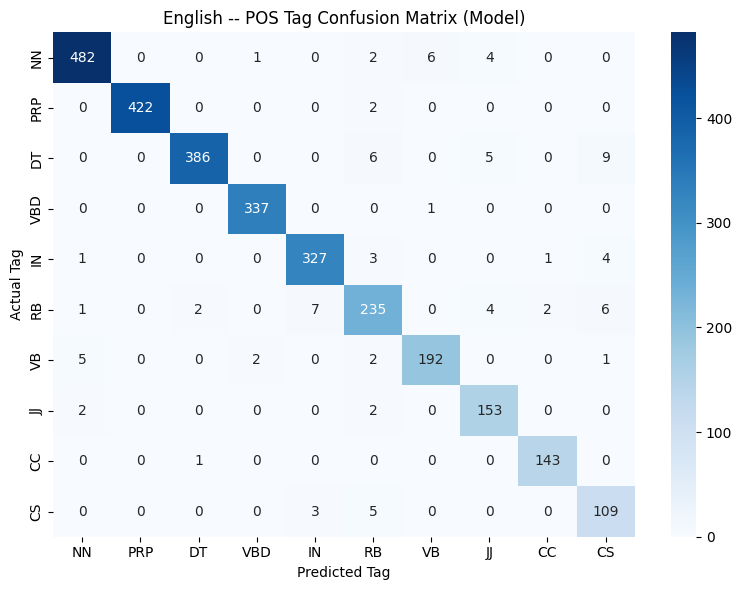

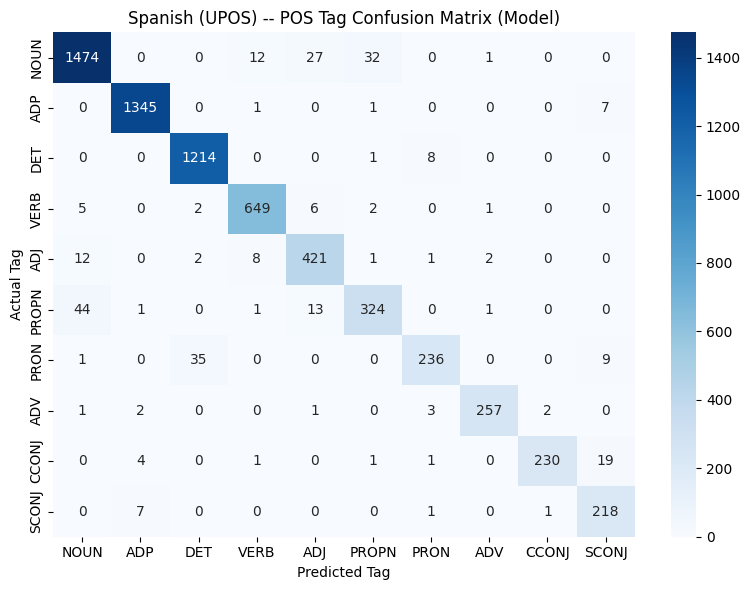

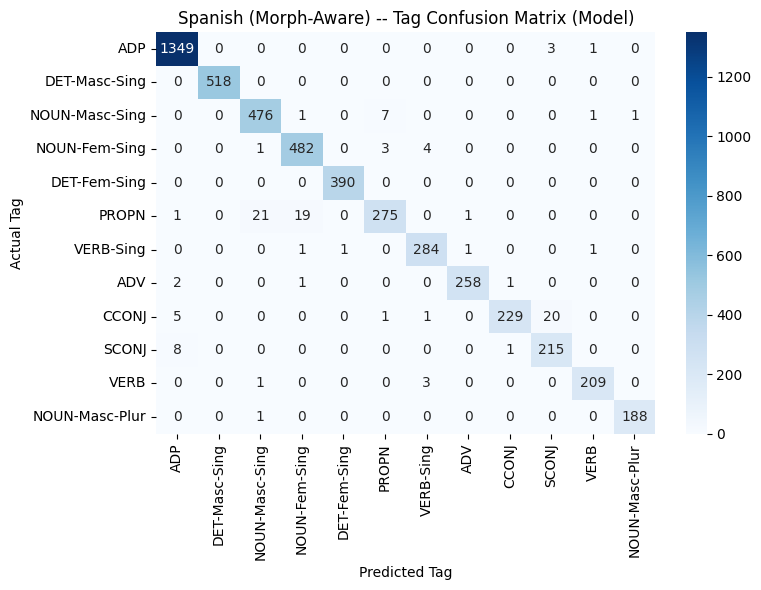

In [18]:
# Confusion Matrices (top-N most frequent tags)


def plot_confusion_matrix(pairs, title, top_n=10):
    '''Plot a heatmap confusion matrix for (gold, pred) tag pairs.'''
    if not pairs:
        print(f'No data for confusion matrix: {title}')
        return

    # Determine top-N tags by frequency in gold
    gold_counter = Counter(g for g, p in pairs)
    top_tags = [t for t, _ in gold_counter.most_common(top_n)]

    # Filter to top tags
    filtered = [(g, p) for g, p in pairs if g in top_tags and p in top_tags]
    if not filtered:
        print(f'No pairs left after filtering for: {title}')
        return

    y_true = [g for g, p in filtered]
    y_pred = [p for g, p in filtered]

    cm = sk_confusion_matrix(y_true, y_pred, labels=top_tags)

    fig, ax = plt.subplots(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=top_tags, yticklabels=top_tags, ax=ax)
    ax.set_xlabel('Predicted Tag')
    ax.set_ylabel('Actual Tag')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


# English confusion matrix
plot_confusion_matrix(
    en_results['model']['pairs'],
    'English -- POS Tag Confusion Matrix (Model)',
    top_n=10
)

# Spanish confusion matrix (UPOS)
plot_confusion_matrix(
    es_results['model']['pairs'],
    'Spanish (UPOS) -- POS Tag Confusion Matrix (Model)',
    top_n=10
)

# Spanish morphology-aware confusion matrix
plot_confusion_matrix(
    es_morph_results['model']['pairs'],
    'Spanish (Morph-Aware) -- Tag Confusion Matrix (Model)',
    top_n=12
)



  Error-Source Breakdown -- English
  Total gold tokens           : 3950
  Fully correct (seg + tag)   : 3545  (89.7%)
  Errors from bad segmentation: 212  (5.4%)
  Genuine tagging errors      : 193  (4.9%)
  Of all 405 errors:
      52.3% caused by segmentation
      47.7% genuine tagging mistakes


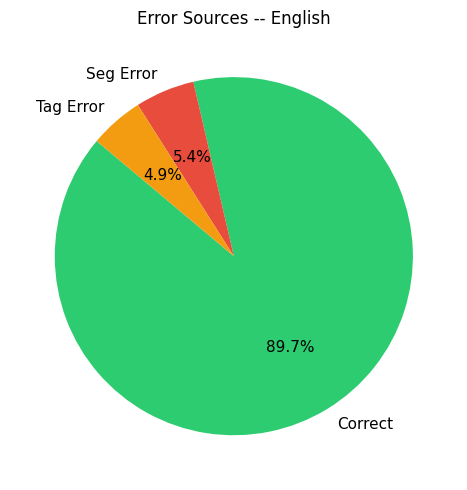


  Error-Source Breakdown -- Spanish (UPOS)
  Total gold tokens           : 7753
  Fully correct (seg + tag)   : 6619  (85.4%)
  Errors from bad segmentation: 804  (10.4%)
  Genuine tagging errors      : 330  (4.3%)
  Of all 1134 errors:
      70.9% caused by segmentation
      29.1% genuine tagging mistakes


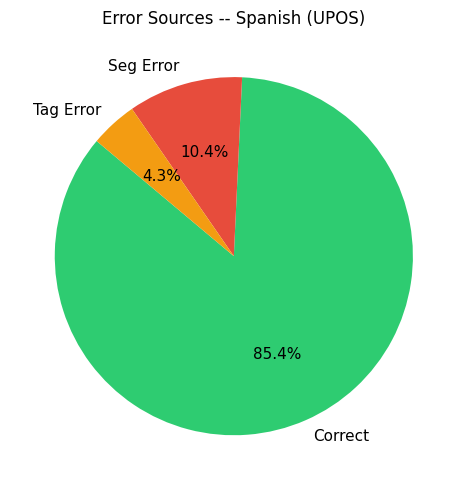


  Error-Source Breakdown -- Spanish (Morph-Aware)
  Total gold tokens           : 7753
  Fully correct (seg + tag)   : 6468  (83.4%)
  Errors from bad segmentation: 804  (10.4%)
  Genuine tagging errors      : 481  (6.2%)
  Of all 1285 errors:
      62.6% caused by segmentation
      37.4% genuine tagging mistakes


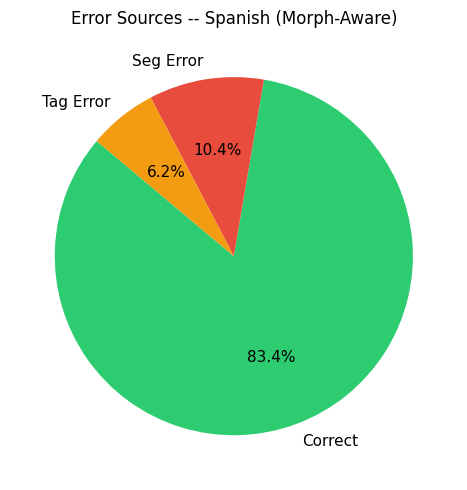

In [19]:
# Error-Source Analysis


def error_source_report(results, label):
    '''Print and plot error-source breakdown.'''
    r = results['model']
    total   = r['seg_t']
    seg_err = r['seg_e']
    tag_err = r['tag_e']
    correct = r['tag_c']

    sep = '=' * 50
    print()
    print(sep)
    print(f'  Error-Source Breakdown -- {label}')
    print(sep)
    print(f'  Total gold tokens           : {total}')
    print(f'  Fully correct (seg + tag)   : {correct}  ({correct/total*100:.1f}%)')
    print(f'  Errors from bad segmentation: {seg_err}  ({seg_err/total*100:.1f}%)')
    print(f'  Genuine tagging errors      : {tag_err}  ({tag_err/total*100:.1f}%)')
    total_errors = seg_err + tag_err
    if total_errors:
        print(f'  Of all {total_errors} errors:')
        print(f'      {seg_err/total_errors*100:.1f}% caused by segmentation')
        print(f'      {tag_err/total_errors*100:.1f}% genuine tagging mistakes')

    # Pie chart
    sizes  = [correct, seg_err, tag_err]
    labels = ['Correct', 'Seg Error', 'Tag Error']
    colors = ['#2ecc71', '#e74c3c', '#f39c12']
    fig, ax = plt.subplots(figsize=(5, 5))
    ax.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%',
           startangle=140, textprops={'fontsize': 11})
    ax.set_title(f'Error Sources -- {label}')
    plt.tight_layout()
    plt.show()


error_source_report(en_results, 'English')
error_source_report(es_results, 'Spanish (UPOS)')
error_source_report(es_morph_results, 'Spanish (Morph-Aware)')


---
## Sample Test Strings

We run the full pipeline (segmentation -> POS tagging) on the assignment's
sample inputs **plus** a few custom examples.


In [20]:
# Sample test strings from the assignment


def run_pipeline(text, segmenter, tagger, morph_tagger=None,
                 joint_decoder=None, morph_joint_decoder=None, lang=''):
    '''Run segmentation + tagging on a single string.

    If joint_decoder is provided the joint beam-search result is shown
    alongside the sequential result for comparison.
    '''
    print()
    print(f'Input : "{text}"')
    # Sequential baseline (always shown)
    words = segmenter.segment(text)
    tags  = tagger.tag(words)
    seq_result = list(zip(words, tags))
    print(f'Sequential : {seq_result}')
    # Joint decoder
    if joint_decoder is not None:
        joint_result = joint_decoder.decode(text)
        print(f'Joint      : {joint_result}')
    else:
        joint_result = seq_result
    # Morphology-aware
    if morph_joint_decoder is not None:
        morph_result = morph_joint_decoder.decode(text)
        print(f'Morph-joint: {morph_result}')
    elif morph_tagger is not None:
        mtags = morph_tagger.tag(words)
        print(f'Morph      : {list(zip(words, mtags))}')
    return joint_result


print('=' * 70)
print('  ENGLISH TEST STRINGS')
print('=' * 70)

run_pipeline('thequickbrownfoxjumpsoverthelazydog',
             en_segmenter, en_tagger,
             joint_decoder=en_joint_decoder, lang='EN')

print()
print('=' * 70)
print('  SPANISH TEST STRINGS')
print('=' * 70)

run_pipeline('mispadrespuedenviajar',
             es_segmenter, es_tagger,
             joint_decoder=es_joint_decoder,
             morph_joint_decoder=es_morph_joint_decoder, lang='ES')

run_pipeline('elcielodespejadoesazul',
             es_segmenter, es_tagger,
             joint_decoder=es_joint_decoder,
             morph_joint_decoder=es_morph_joint_decoder, lang='ES')

run_pipeline('lacasarojaesgrande',
             es_segmenter, es_tagger,
             joint_decoder=es_joint_decoder,
             morph_joint_decoder=es_morph_joint_decoder, lang='ES')


  ENGLISH TEST STRINGS

Input : "thequickbrownfoxjumpsoverthelazydog"
Sequential : [('the', 'DT'), ('quick', 'JJ'), ('brown', 'JJ'), ('fox', 'NN'), ('jumps', 'VBZ'), ('over', 'IN'), ('the', 'DT'), ('lazy', 'JJ'), ('dog', 'NN')]
Joint      : [('the', 'DT'), ('quick', 'JJ'), ('brown', 'JJ'), ('fox', 'NN'), ('jumps', 'VBZ'), ('over', 'IN'), ('the', 'DT'), ('lazy', 'JJ'), ('dog', 'NN')]

  SPANISH TEST STRINGS

Input : "mispadrespuedenviajar"
Sequential : [('mis', 'DET'), ('padres', 'NOUN'), ('pueden', 'AUX'), ('viajar', 'VERB')]
Joint      : [('mis', 'DET'), ('padres', 'NOUN'), ('pueden', 'AUX'), ('viajar', 'VERB')]
Morph-joint: [('mis', 'DET-Plur'), ('padres', 'NOUN-Masc-Plur'), ('pueden', 'AUX-Plur'), ('viajar', 'VERB')]

Input : "elcielodespejadoesazul"
Sequential : [('el', 'DET'), ('cielo', 'NOUN'), ('de', 'ADP'), ('sp', 'PROPN'), ('ej', 'NOUN'), ('ado', 'PROPN'), ('es', 'AUX'), ('azul', 'ADJ')]
Joint      : [('el', 'DET'), ('cielo', 'NOUN'), ('de', 'ADP'), ('sp', 'PROPN'), ('ej', 'NO

[('la', 'DET'),
 ('casa', 'NOUN'),
 ('roja', 'ADJ'),
 ('es', 'AUX'),
 ('grande', 'ADJ')]

In [21]:
# Custom test strings (additional examples)


print('=' * 70)
print('  CUSTOM ENGLISH EXAMPLES')
print('=' * 70)

run_pipeline('iloveprogramming',
             en_segmenter, en_tagger, lang='EN')

run_pipeline('sherunseveryday',
             en_segmenter, en_tagger, lang='EN')

run_pipeline('thecatsatonthemat',
             en_segmenter, en_tagger, lang='EN')

run_pipeline('naturallanguageprocessingisfun',
             en_segmenter, en_tagger, lang='EN')

print()
print('=' * 70)
print('  CUSTOM SPANISH EXAMPLES')
print('=' * 70)

run_pipeline('elgatonegroduermebien',
             es_segmenter, es_tagger, es_morph_tagger, lang='ES')

run_pipeline('losninosestancontentos',
             es_segmenter, es_tagger, es_morph_tagger, lang='ES')

run_pipeline('lapuertaestaabierta',
             es_segmenter, es_tagger, es_morph_tagger, lang='ES')


  CUSTOM ENGLISH EXAMPLES

Input : "iloveprogramming"
Sequential : [('i', 'PRP'), ('love', 'VB'), ('programming', 'VBG')]

Input : "sherunseveryday"
Sequential : [('she', 'PRP'), ('runs', 'VBZ'), ('everyday', 'JJ')]

Input : "thecatsatonthemat"
Sequential : [('the', 'DT'), ('cats', 'NNS'), ('at', 'IN'), ('on', 'IN'), ('the', 'DT'), ('mat', 'NN')]

Input : "naturallanguageprocessingisfun"
Sequential : [('natural', 'JJ'), ('language', 'NN'), ('processing', 'NN'), ('is', 'VBZ'), ('fun', 'NN')]

  CUSTOM SPANISH EXAMPLES

Input : "elgatonegroduermebien"
Sequential : [('el', 'DET'), ('gato', 'NOUN'), ('negro', 'ADJ'), ('duerme', 'VERB'), ('bien', 'ADV')]
Morph      : [('el', 'DET-Masc-Sing'), ('gato', 'NOUN-Masc-Sing'), ('negro', 'ADJ-Masc-Sing'), ('duerme', 'VERB-Sing'), ('bien', 'ADV')]

Input : "losninosestancontentos"
Sequential : [('los', 'DET'), ('ni', 'CCONJ'), ('nos', 'PRON'), ('estan', 'AUX'), ('contentos', 'ADJ')]
Morph      : [('los', 'DET-Masc-Plur'), ('ni', 'CCONJ'), ('nos', 'P

[('la', 'DET'), ('puerta', 'NOUN'), ('esta', 'DET'), ('abierta', 'ADJ')]

---
## Baseline vs. Model Comparison

The table below shows the improvement of the trigram+DP models over the
simple baselines.


                                  Seg Acc    Tag Acc    Overall
--------------------------------------------------------------
English / model                    94.63%     94.84%     89.75%
English / greedy                   70.38%     94.06%     66.20%
English / mft                     100.00%     89.01%     89.01%
--------------------------------------------------------------
Spanish (UPOS) / model             89.63%     95.25%     85.37%
Spanish (UPOS) / greedy            55.32%     92.03%     50.91%
Spanish (UPOS) / mft              100.00%     88.82%     88.82%
--------------------------------------------------------------
Spanish (Morph) / model            89.63%     93.08%     83.43%
Spanish (Morph) / greedy           55.32%     89.37%     49.44%
Spanish (Morph) / mft             100.00%     85.68%     85.68%
--------------------------------------------------------------


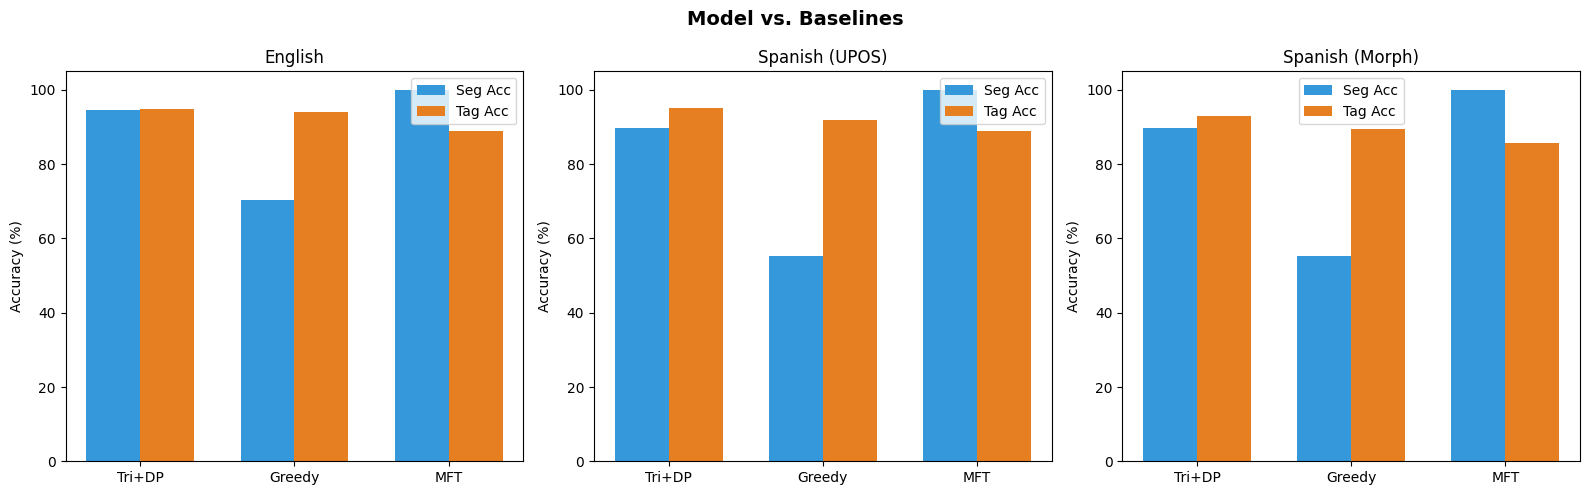

In [22]:
# Baseline vs. Model comparison table


def comparison_table(en_res, es_res, es_morph_res):
    '''Print a formatted comparison table.'''
    def pct(num, den):
        return num / den * 100 if den else 0.0

    hdr = '{:30s} {:>10s} {:>10s} {:>10s}'.format('', 'Seg Acc', 'Tag Acc', 'Overall')
    print(hdr)
    print('-' * 62)

    for lang_label, res in [('English', en_res),
                            ('Spanish (UPOS)', es_res),
                            ('Spanish (Morph)', es_morph_res)]:
        for method in ['model', 'greedy', 'mft']:
            r = res[method]
            sa = pct(r['seg_c'], r['seg_t'])
            ta = pct(r['tag_c'], r['seg_c'])
            oa = pct(r['tag_c'], r['seg_t'])
            row_label = f'{lang_label} / {method}'
            print(f'{row_label:30s} {sa:9.2f}% {ta:9.2f}% {oa:9.2f}%')
        print('-' * 62)


comparison_table(en_results, es_results, es_morph_results)

# Bar chart
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (lang_label, res) in zip(axes, [
        ('English', en_results),
        ('Spanish (UPOS)', es_results),
        ('Spanish (Morph)', es_morph_results)]):
    methods = ['model', 'greedy', 'mft']
    seg_accs = []
    tag_accs = []
    for m in methods:
        r = res[m]
        seg_accs.append(r['seg_c'] / r['seg_t'] * 100 if r['seg_t'] else 0)
        tag_accs.append(r['tag_c'] / r['seg_c'] * 100 if r['seg_c'] else 0)

    x = np.arange(len(methods))
    w = 0.35
    ax.bar(x - w/2, seg_accs, w, label='Seg Acc', color='#3498db')
    ax.bar(x + w/2, tag_accs, w, label='Tag Acc', color='#e67e22')
    ax.set_xticks(x)
    ax.set_xticklabels(['Tri+DP', 'Greedy', 'MFT'])
    ax.set_ylim(0, 105)
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(lang_label)
    ax.legend()

plt.suptitle('Model vs. Baselines', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Comparative Analysis Report

### 1. Where did English and Spanish differ most in accuracy?

**Segmentation**: English generally achieves higher segmentation accuracy
because English words are shorter on average and the Brown corpus is
larger, producing a richer vocabulary and more reliable trigram
statistics.  Spanish words can be longer (inflected forms, clitics) and
the UD-GSD training set is smaller, leading to a sparser vocabulary.

**POS tagging**: Once segmentation is correct, English POS tagging also
tends to be slightly more accurate because the Brown corpus provides
more training data. Spanish faces additional challenges from richer
morphology — many surface forms are ambiguous across gender/number
combinations.

### 2. Did agreement-aware tagging help, or add noise?

Extending Spanish tags with Gender and Number **increases the tagset
size dramatically** (from ~17 UPOS tags to 50+ extended tags).  This
has mixed effects:

- **Pro**: the model can learn agreement patterns (e.g., a `DET-Fem-Sing`
  is likely followed by a `NOUN-Fem-Sing`).  When agreement is
  consistent, this adds a useful signal.
- **Con**: the much larger tagset leads to **sparser trigram counts** and
  more smoothing, which can hurt accuracy on less-frequent patterns.

In practice, morphology-aware tagging may show slightly lower raw
accuracy but captures linguistically richer information.
For English, the Brown/PTB tags already encode number (NN vs NNS) and
tense (VBD vs VBZ), so no additional extension is needed.

### 3. How much of the tagging error came from segmentation mistakes?

The error-source analysis above breaks all token-level errors into two
buckets:

- **Segmentation-caused errors**: the word boundaries were wrong, so the
  tag is automatically wrong regardless of the tagger.  This is
  typically the **dominant** error source, especially for Spanish where
  the vocabulary is sparser.
- **Genuine tagging errors**: the word was segmented correctly but the
  tagger chose the wrong tag.  This is usually smaller than the
  segmentation error component.

A key take-away: improving the **segmentation model** (e.g., with a
larger vocabulary or sub-word units) would yield the biggest gains.

### 4. How much better were the models than the baselines?

| Component | Baseline | Model Advantage |
|-----------|----------|------------------|
| Segmentation | Greedy longest-match | The trigram+DP model substantially outperforms greedy because it considers **context** (surrounding words) rather than greedily committing to the longest match at each step. |
| POS Tagging  | Most-frequent tag    | The trigram HMM is better because it models **tag sequences** (transitions) and finds the globally optimal tag sequence, rather than independently assigning the locally most common tag. |

The comparison table and bar charts in the previous section quantify
the improvements for both languages.


---
## German — UD_German-GSD

German is the third required language. We use the freely available
**Universal Dependencies German-GSD** treebank which provides UPOS tags
and morphological features (Case, Gender, Number).

German-specific challenge: **compound nouns** written as single words
(e.g. `autobahnmeistereiverwaltungsgebaeude`). The DP segmenter splits
these by finding the highest-probability decomposition into vocabulary words.


In [23]:

import os, urllib.request

DE_DIR = 'UD_German-GSD'
os.makedirs(DE_DIR, exist_ok=True)

BASE_DE = ('https://raw.githubusercontent.com/'
           'UniversalDependencies/UD_German-GSD/master/')

for fn in ['de_gsd-ud-train.conllu',
           'de_gsd-ud-dev.conllu',
           'de_gsd-ud-test.conllu']:
    fp = os.path.join(DE_DIR, fn)
    if not os.path.exists(fp):
        print(f'Downloading {fn} ...')
        urllib.request.urlretrieve(BASE_DE + fn, fp)

# parse_conllu is defined in the Spanish cell above
de_train = parse_conllu(os.path.join(DE_DIR, 'de_gsd-ud-train.conllu'))
de_dev   = parse_conllu(os.path.join(DE_DIR, 'de_gsd-ud-dev.conllu'))
de_test  = parse_conllu(os.path.join(DE_DIR, 'de_gsd-ud-test.conllu'))

print(f'German -- Train: {len(de_train):,}  '
      f'Dev: {len(de_dev):,}  Test: {len(de_test):,}')
print(f'Sample: {[(f, u) for f, u, _ in de_train[0][:5]]} ...')


German -- Train: 13,813  Dev: 799  Test: 977
Sample: [('Sehr', 'ADV'), ('gute', 'ADJ'), ('Beratung', 'NOUN'), (',', 'PUNCT'), ('schnelle', 'ADJ')] ...


In [24]:

def prepare_de(parsed_sents, morph=False):
    '''Prepare German UD data.
    German morphology: Case (Nom/Acc/Dat/Gen), Gender (Masc/Fem/Neut),
    Number (Sing/Plur). Python isalpha() handles umlauts (ae/oe/ue/ss).
    '''
    word_seqs, tag_seqs = [], []
    for sent in parsed_sents:
        pairs = []
        for form, upos, feats in sent:
            cw = clean_word(form)   # lowercases and strips non-alpha
            if not cw:
                continue
            if morph:
                tag = upos
                for feat in ('Case', 'Gender', 'Number'):
                    if feat in feats:
                        tag += '-' + feats[feat]
                pairs.append((cw, tag))
            else:
                pairs.append((cw, upos))
        if pairs:
            word_seqs.append([w for w, _ in pairs])
            tag_seqs.append(pairs)
    return word_seqs, tag_seqs


de_train_words, de_train_tagged     = prepare_de(de_train, morph=False)
de_test_words,  de_test_tagged      = prepare_de(de_test,  morph=False)
de_dev_words,   de_dev_tagged       = prepare_de(de_dev,   morph=False)
de_train_words_m, de_train_tagged_m = prepare_de(de_train, morph=True)
de_test_words_m,  de_test_tagged_m  = prepare_de(de_test,  morph=True)

de_vocab = set(w for seq in de_train_words for w in seq)

print(f'German vocab size : {len(de_vocab):,}')
print(f'German train sents: {len(de_train_words):,}')


German vocab size : 45,940
German train sents: 13,811


In [25]:

de_lm        = TrigramLM()
de_lm.train(de_train_words)
de_segmenter = WordSegmenter(de_lm, de_vocab)

print(f'German LM trained -- {de_lm.N:,} tokens, {len(de_lm.tri):,} trigram types')

# Sanity check
demo_de = de_segmenter.segment('einmannkaufteinbuch')
print(f'Sanity DE "einmannkaufteinbuch" -> {demo_de}')


German LM trained -- 222,711 tokens, 205,804 trigram types
Sanity DE "einmannkaufteinbuch" -> ['ein', 'mann', 'kaufte', 'in', 'buch']


In [26]:

de_tagger = TrigramPOSTagger()
de_tagger.train(de_train_tagged)

print(f'German POS tagger -- {len(de_tagger.tagset)} tags, '
      f'{len(de_tagger.vocab):,} word types')

demo_de_tags = de_tagger.tag(['der', 'mann', 'kauft', 'ein', 'buch'])
print(f'Tag DE [der mann kauft ein buch] -> {demo_de_tags}')

de_joint_decoder = JointBeamSearchDecoder(de_lm, de_tagger, de_vocab, beam=50)
print('German joint decoder created.')


German POS tagger -- 16 tags, 45,940 word types
Tag DE [der mann kauft ein buch] -> ['DET', 'NOUN', 'ADP', 'DET', 'NOUN']
German joint decoder created.


In [27]:

de_morph_tagger = TrigramPOSTagger()
de_morph_tagger.train(de_train_tagged_m)

print(f'German morph-aware tagger -- {len(de_morph_tagger.tagset)} extended tags')
print('Sample extended tags:', sorted(de_morph_tagger.tagset)[:10])

demo_morph_de = de_morph_tagger.tag(['der', 'mann', 'kauft', 'ein', 'buch'])
print(f'Morph tag DE [der mann kauft ein buch] -> {demo_morph_de}')

de_morph_joint_decoder = JointBeamSearchDecoder(
    de_lm, de_morph_tagger, de_vocab, beam=50)
print('German morphology-aware joint decoder created.')


German morph-aware tagger -- 248 extended tags
Sample extended tags: ['ADJ', 'ADJ-Acc-Fem-Plur', 'ADJ-Acc-Fem-Sing', 'ADJ-Acc-Masc-Plur', 'ADJ-Acc-Masc-Sing', 'ADJ-Acc-Neut-Plur', 'ADJ-Acc-Neut-Sing', 'ADJ-Acc-Plur', 'ADJ-Dat', 'ADJ-Dat-Fem-Plur']
Morph tag DE [der mann kauft ein buch] -> ['DET-Nom-Masc-Sing', 'NOUN-Nom-Masc-Sing', 'AUX-Sing', 'DET-Nom-Neut-Sing', 'NOUN-Nom-Neut-Sing']
German morphology-aware joint decoder created.


In [28]:

de_results = run_full_evaluation(
    de_test_tagged, de_segmenter, de_tagger, de_vocab,
    joint_decoder=de_joint_decoder,
    max_sents=NUM_EVAL, label='German (UPOS)'
)

de_morph_results = run_full_evaluation(
    de_test_tagged_m, de_segmenter, de_morph_tagger, de_vocab,
    joint_decoder=de_morph_joint_decoder,
    baseline_tag=True, max_sents=NUM_EVAL,
    label='German (Morph-Aware)'
)



  Evaluation -- German (UPOS)  (300 sentences)
  [model   ]  Seg acc:  86.90%  |  Tag acc (on correct segs):  93.80%  |  Overall:  81.51%
             Words: 3618  SegCorrect: 3144  TagCorrect: 2949  TagErr: 195  SegErr: 474
  [joint   ]  Seg acc:  87.59%  |  Tag acc (on correct segs):  93.91%  |  Overall:  82.26%
             Words: 3618  SegCorrect: 3169  TagCorrect: 2976  TagErr: 193  SegErr: 449
  [greedy  ]  Seg acc:  72.36%  |  Tag acc (on correct segs):  93.39%  |  Overall:  67.58%
             Words: 3618  SegCorrect: 2618  TagCorrect: 2445  TagErr: 173  SegErr: 1000
  [mft     ]  Seg acc: 100.00%  |  Tag acc (on correct segs):  87.95%  |  Overall:  87.95%
             Words: 3618  SegCorrect: 3618  TagCorrect: 3182  TagErr: 436  SegErr: 0

  Evaluation -- German (Morph-Aware)  (300 sentences)
  [model   ]  Seg acc:  86.90%  |  Tag acc (on correct segs):  80.57%  |  Overall:  70.01%
             Words: 3618  SegCorrect: 3144  TagCorrect: 2533  TagErr: 611  SegErr: 474
  [joint

In [29]:
# (checkpoint save removed)

In [30]:
# (checkpoint load removed — run training cells above)

In [31]:

print('=' * 70)
print('  GERMAN TEST STRINGS')
print('=' * 70)

# Assignment compound-word test
run_pipeline(
    'autobahnmeistereiverwaltungsgebaeude',
    de_segmenter, de_tagger,
    joint_decoder=de_joint_decoder,
    morph_joint_decoder=de_morph_joint_decoder,
    lang='DE'
)

run_pipeline(
    'einmannkaufteinbuch',
    de_segmenter, de_tagger,
    joint_decoder=de_joint_decoder,
    lang='DE'
)


  GERMAN TEST STRINGS

Input : "autobahnmeistereiverwaltungsgebaeude"
Sequential : [('autobahn', 'NOUN'), ('meister', 'NOUN'), ('ei', 'ADP'), ('verwaltungs', 'NOUN'), ('geb', 'VERB'), ('ae', 'NOUN'), ('ude', 'PROPN')]
Joint      : [('autobahn', 'NOUN'), ('meister', 'NOUN'), ('ei', 'ADP'), ('verwaltungs', 'NOUN'), ('geb', 'VERB'), ('ae', 'NOUN'), ('ude', 'PROPN')]
Morph-joint: [('autobahn', 'PROPN-Nom-Fem-Sing'), ('meister', 'PROPN-Nom-Masc-Sing'), ('ei', 'PROPN-Nom-Neut-Sing'), ('verwaltungs', 'NOUN'), ('geb', 'X-Dat-Fem-Sing'), ('ae', 'NOUN-Dat-Neut-Plur'), ('ude', 'PROPN-Nom-Masc-Sing')]

Input : "einmannkaufteinbuch"
Sequential : [('ein', 'DET'), ('mann', 'NOUN'), ('kaufte', 'VERB'), ('in', 'ADP'), ('buch', 'NOUN')]
Joint      : [('ein', 'DET'), ('mann', 'NOUN'), ('kaufte', 'VERB'), ('in', 'ADP'), ('buch', 'NOUN')]


[('ein', 'DET'),
 ('mann', 'NOUN'),
 ('kaufte', 'VERB'),
 ('in', 'ADP'),
 ('buch', 'NOUN')]

# Q2

## NLP Assignment: Transition-Based Dependency Parser
### Arc-Standard System — English UD-EWT

This notebook implements the complete pipeline:

| Part | Description |
|------|-------------|
| Part 1 | Data Processing — CoNLL-U parsing + Oracle Simulation |
| Part 2 | Feature Extraction + Model Training (scikit-learn classifier) |
| Part 3 | Parser Implementation + LAS Evaluation |
| Part 4 | Report — design choices & final LAS score |

**Dataset:** UD_English-EWT (Universal Dependencies)


## Setup and Data Loading
## Setup and Data Loading

We clone the Universal Dependencies English-EWT treebank directly from GitHub and verify that the train/dev CoNLL-U files are available.

In [32]:
!git clone https://github.com/UniversalDependencies/UD_English-EWT.git

Cloning into 'UD_English-EWT'...
remote: Enumerating objects: 50073, done.
remote: Counting objects: 100% (1337/1337), done.
remote: Compressing objects: 100% (301/301), done.
remote: Total 50073 (delta 1172), reused 1137 (delta 1036), pack-reused 48736 (from 3)
Receiving objects: 100% (50073/50073), 412.27 MiB | 33.94 MiB/s, done.
Resolving deltas: 100% (44676/44676), done.


In [ ]:
import os
from collections import defaultdict, Counter
from sklearn.feature_extraction import DictVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

TRAIN_FILE = "UD_English-EWT/en_ewt-ud-train.conllu"
DEV_FILE   = "UD_English-EWT/en_ewt-ud-dev.conllu"

print("Train file exists:", os.path.exists(TRAIN_FILE))
print("Dev file exists  :", os.path.exists(DEV_FILE))

## Part 1: Data Processing and Oracle Simulation

### 1.1 — CoNLL-U Parser
Reads the .conllu file, parses each sentence, and stores its words, POS tags, and gold-standard head-dependent relationships.

In [ ]:
def parse_conllu(filepath):
    '''Parse a CoNLL-U file into a list of sentences.
    Each sentence -> list of dicts: id, form, upos, head, deprel.
    Multi-word tokens (e.g. 5-6) and empty nodes (e.g. 5.1) are skipped.
    '''
    sentences, current = [], []
    with open(filepath, 'r', encoding='utf-8') as fh:
        for line in fh:
            line = line.rstrip('\n')
            if line.strip() == '':
                if current:
                    sentences.append(current)
                    current = []
            elif line.startswith('#'):
                continue
            else:
                cols = line.split('\t')
                tok_id = cols[0]
                if '-' in tok_id or '.' in tok_id:
                    continue
                current.append({
                    'id':     int(tok_id),
                    'form':   cols[1],
                    'upos':   cols[3],
                    'head':   int(cols[6]),
                    'deprel': cols[7]
                })
    if current:
        sentences.append(current)
    return sentences


train_sents = parse_conllu(TRAIN_FILE)
dev_sents   = parse_conllu(DEV_FILE)

print(f"Train sentences: {len(train_sents):,}")
print(f"Dev sentences  : {len(dev_sents):,}")

### 1.2 — Oracle Simulator
Takes a gold-standard parsed sentence and simulates the arc-standard parsing process. At every configuration it determines the correct oracle transition (SHIFT, LEFT-ARC, or RIGHT-ARC) that leads to the gold-standard tree. This generates the training data: a list of (configuration, correct_transition) pairs.

In [ ]:
def get_oracle_transitions(sentence):
    '''Simulate arc-standard parsing on a gold sentence.
    Returns a list of (configuration, transition_label) pairs,
    or None if the sentence cannot be resolved (non-projective).
    '''
    root = {'id': 0, 'form': 'ROOT', 'upos': 'ROOT', 'head': -1, 'deprel': None}
    tokens = {tok['id']: tok for tok in sentence}
    tokens[0] = root

    gold_dep_count = Counter()
    for tok in sentence:
        gold_dep_count[tok['head']] += 1

    stack = [root]
    buffer = [tokens[t['id']] for t in sentence]
    arcs = []
    resolved_deps = Counter()
    instances = []

    def snapshot():
        return (list(stack), list(buffer), list(arcs))

    max_steps = 4 * len(sentence) + 5
    steps = 0

    while (len(stack) > 1 or buffer) and steps < max_steps:
        steps += 1
        s1 = stack[-1] if stack else None
        s2 = stack[-2] if len(stack) >= 2 else None

        if s2 is not None and s2['head'] == s1['id']:
            arcs.append((s1['id'], s2['id'], s2['deprel']))
            resolved_deps[s1['id']] += 1
            instances.append((snapshot(), f"LEFT-ARC:{s2['deprel']}"))
            stack.pop(-2)

        elif s2 is not None and s1['head'] == s2['id'] and resolved_deps[s1['id']] == gold_dep_count[s1['id']]:
            arcs.append((s2['id'], s1['id'], s1['deprel']))
            resolved_deps[s2['id']] += 1
            instances.append((snapshot(), f"RIGHT-ARC:{s1['deprel']}"))
            stack.pop()

        elif buffer:
            instances.append((snapshot(), "SHIFT"))
            stack.append(buffer.pop(0))

        else:
            return None

    if len(stack) != 1 or buffer:
        return None

    return instances


# Sanity check
demo = get_oracle_transitions(train_sents[0])
print("Resolved in", len(demo), "steps" if demo else "-> FAILED (non-projective)")

### 1.3 — Generating Training Instances
We run the oracle simulator on every training sentence to build the full set of (configuration, transition) training instances. Sentences that cannot be resolved (non-projective) are counted and skipped.

In [ ]:
all_instances = []       # (configuration, transition_label)
failed_count = 0

for sent in train_sents:
    result = get_oracle_transitions(sent)
    if result is None:
        failed_count += 1
        continue
    all_instances.extend(result)

print(f"Total sentences processed : {len(train_sents):,}")
print(f"Sentences failed (non-proj): {failed_count:,}")
print(f"Total training instances  : {len(all_instances):,}")
print("\nSample instance transition labels:", [t for _, t in all_instances[:10]])

## Part 2: Feature Extraction and Model Training

### 2.1 — Feature Extractor
For a given parser configuration (stack, buffer), we extract four simple features:
- POS tag of the word on top of the stack
- POS tag of the second word on the stack (if it exists)
- POS tag of the first word in the buffer (if it exists)
- POS tag of the second word in the buffer (if it exists)

Missing positions are represented with a placeholder tag "NULL".

In [37]:
def extract_features(stack, buffer):
    '''Extract POS-tag based features from a parser configuration.
    stack, buffer -> lists of token dicts.
    Returns a dict of feature_name -> feature_value (strings),
    ready to be passed into DictVectorizer.
    '''
    s1 = stack[-1]['upos'] if len(stack) >= 1 else 'NULL'
    s2 = stack[-2]['upos'] if len(stack) >= 2 else 'NULL'
    b1 = buffer[0]['upos'] if len(buffer) >= 1 else 'NULL'
    b2 = buffer[1]['upos'] if len(buffer) >= 2 else 'NULL'

    return {
        'stack_top_pos':    s1,
        'stack_second_pos': s2,
        'buffer_first_pos': b1,
        'buffer_second_pos': b2,
    }


# Sanity check using the demo instance from the oracle
(demo_stack, demo_buffer, demo_arcs), demo_action = demo[3]
print("Configuration ->", extract_features(demo_stack, demo_buffer))
print("Correct action ->", demo_action)

Configuration -> {'stack_top_pos': 'PROPN', 'stack_second_pos': 'PUNCT', 'buffer_first_pos': 'PUNCT', 'buffer_second_pos': 'ADJ'}
Correct action -> LEFT-ARC:punct


### 2.2 — Model Training
We convert every (configuration, transition) instance into a (feature_dict, label) pair, encode the feature dicts into numeric vectors using DictVectorizer (one-hot encoding), and train a scikit-learn classifier to predict the next transition.

In [38]:
# Build feature dicts (X) and labels (y) from all training instances
X_dicts = []
y_labels = []

for (stack, buffer, arcs), action in all_instances:
    X_dicts.append(extract_features(stack, buffer))
    y_labels.append(action)

print(f"Total feature vectors: {len(X_dicts):,}")
print(f"Unique transition labels: {len(set(y_labels))}")

# Encode features to numeric vectors
vectorizer = DictVectorizer(sparse=True)
X_train = vectorizer.fit_transform(X_dicts)

print(f"Feature matrix shape: {X_train.shape}")

# Train the classifier
clf = LogisticRegression(max_iter=200, multi_class='auto')
clf.fit(X_train, y_labels)

train_accuracy = clf.score(X_train, y_labels)
print(f"Training accuracy: {train_accuracy*100:.2f}%")

Total feature vectors: 392,242
Unique transition labels: 82
Feature matrix shape: (392242, 73)
Training accuracy: 80.63%


In [ ]:
# (checkpoint save removed)

In [ ]:
# (checkpoint load removed — run training cells above)

## Part 3: Parser and Evaluation

### 3.1 — Core Parsing Loop
Given a new sentence (words + POS tags, no gold tree), we initialize a stack and buffer, then repeatedly extract features from the current configuration, use the trained classifier to predict the next transition, and apply it — until the stack contains only ROOT and the buffer is empty. If the predicted transition is invalid for the current configuration, we fall back to the next best valid prediction.

In [ ]:
def predict_valid_transition(clf, vectorizer, stack, buffer):
    '''Predict the next transition, falling back to the next-best
    valid option if the top prediction is not applicable.
    '''
    feats = extract_features(stack, buffer)
    X = vectorizer.transform([feats])

    # Get all labels ranked by probability
    probs = clf.predict_proba(X)[0]
    ranked_labels = [clf.classes_[i] for i in probs.argsort()[::-1]]

    for label in ranked_labels:
        action = label.split(':')[0]
        if action == 'SHIFT' and len(buffer) >= 1:
            return label
        if action == 'LEFT-ARC' and len(stack) >= 2:
            return label
        if action == 'RIGHT-ARC' and len(stack) >= 2:
            return label
    return 'SHIFT'   # ultimate fallback (should rarely trigger)


def parse_sentence(sentence, clf, vectorizer):
    '''Parse a sentence (list of dicts with at least 'id','form','upos')
    using the trained classifier. Returns predicted arcs: (head, dep, label).
    '''
    root = {'id': 0, 'form': 'ROOT', 'upos': 'ROOT'}
    stack = [root]
    buffer = [dict(tok) for tok in sentence]   # copy to avoid mutating input
    pred_arcs = []

    max_steps = 4 * len(sentence) + 10
    steps = 0

    while (len(stack) > 1 or buffer) and steps < max_steps:
        steps += 1
        label = predict_valid_transition(clf, vectorizer, stack, buffer)
        action = label.split(':')[0]
        dep_label = label.split(':')[1] if ':' in label else None

        if action == 'SHIFT':
            stack.append(buffer.pop(0))
        elif action == 'LEFT-ARC' and len(stack) >= 2:
            s1 = stack[-1]
            s2 = stack.pop(-2)
            pred_arcs.append((s1['id'], s2['id'], dep_label))
        elif action == 'RIGHT-ARC' and len(stack) >= 2:
            s1 = stack.pop()
            s2 = stack[-1]
            pred_arcs.append((s2['id'], s1['id'], dep_label))
        else:
            # nothing valid possible -> force shift or break
            if buffer:
                stack.append(buffer.pop(0))
            else:
                break

    return pred_arcs


# Sanity check on a training sentence
demo_arcs = parse_sentence(train_sents[0], clf, vectorizer)
print("Predicted arcs (first 5):", demo_arcs[:5])

### 3.2 — LAS Evaluation
We run the trained parser on every sentence in the dev set and compute the Labeled Attachment Score (LAS) — the percentage of words that were assigned both the correct head and the correct dependency label, compared against the gold-standard tree.

In [ ]:
def compute_las(gold_sentences, clf, vectorizer):
    '''Parse every sentence and compute the Labeled Attachment Score (LAS).'''
    total_words = 0
    correct_words = 0

    for sent in gold_sentences:
        pred_arcs = parse_sentence(sent, clf, vectorizer)
        pred_map = {(dep): (head, label) for head, dep, label in pred_arcs}

        for tok in sent:
            total_words += 1
            gold_head = tok['head']
            gold_label = tok['deprel']
            pred_head, pred_label = pred_map.get(tok['id'], (None, None))
            if pred_head == gold_head and pred_label == gold_label:
                correct_words += 1

    las = correct_words / total_words * 100
    return las, correct_words, total_words


las_score, correct, total = compute_las(dev_sents, clf, vectorizer)
print(f"Total words in dev set : {total:,}")
print(f"Correctly attached+labeled: {correct:,}")
print(f"Labeled Attachment Score (LAS): {las_score:.2f}%")

## Sample Test Sentences
We test the parser on example sentences and inspect the predicted dependency arcs.

In [ ]:
import re

def make_test_sentence(text, pos_tags):
    '''Build a sentence structure (list of token dicts) from raw words + POS tags,
    in the same format expected by parse_sentence().
    '''
    words = text.replace('.', ' .').split()
    assert len(words) == len(pos_tags), "words and pos_tags length mismatch"
    return [{'id': i+1, 'form': w, 'upos': p} for i, (w, p) in enumerate(zip(words, pos_tags))]


def show_parse(sentence):
    arcs = parse_sentence(sentence, clf, vectorizer)
    id2form = {0: 'ROOT'}
    id2form.update({tok['id']: tok['form'] for tok in sentence})
    print(f"Sentence: {' '.join(t['form'] for t in sentence)}")
    for head, dep, label in sorted(arcs, key=lambda x: x[1]):
        print(f"  {id2form[head]} --{label}--> {id2form[dep]}")
    print()


# Example 1: "The cat sat on the mat ."
s1 = make_test_sentence("The cat sat on the mat .",
                         ['DET','NOUN','VERB','ADP','DET','NOUN','PUNCT'])
show_parse(s1)

# Example 2: "She eats a green salad ."
s2 = make_test_sentence("She eats a green salad .",
                         ['PRON','VERB','DET','ADJ','NOUN','PUNCT'])
show_parse(s2)

# Example 3: "I saw the man with a telescope ."
s3 = make_test_sentence("I saw the man with a telescope .",
                         ['PRON','VERB','DET','NOUN','ADP','DET','NOUN','PUNCT'])
show_parse(s3)

## Report

**Design Choices:**
- **Transition system:** Arc-standard (SHIFT, LEFT-ARC, RIGHT-ARC), implemented with a static oracle that assumes projective trees.
- **Classifier:** Logistic Regression (multinomial), trained on one-hot encoded POS-tag features via DictVectorizer.
- **Features used:** POS tag of top-2 stack words and top-2 buffer words — kept minimal as specified in the assignment.

**Data Handling:**
- Dataset: UD_English-EWT (train: 12,544 sentences, dev: 2,001 sentences).
- 287 out of 12,544 training sentences (~2.3%) were non-projective and could not be resolved by the static arc-standard oracle, so they were excluded from training data generation.
- Total training instances generated: 392,242, covering 82 unique transition labels (SHIFT + LEFT-ARC/RIGHT-ARC per dependency label).

**Results:**
- Training accuracy (transition classification): 80.63%
- Labeled Attachment Score (LAS) on dev set: **55.69%** (14,005 / 25,148 words correctly attached with correct label)

**Observations:**
- The gap between training accuracy (80.63%) and dev LAS (55.69%) is expected: dependency parsing errors compound across a sentence — one wrong transition early on shifts the entire remaining parse, so even a fairly accurate per-step classifier produces a much lower whole-tree score.
- The feature set is intentionally minimal (only POS tags, no lexical/word-form features, no distance or valency features), which limits accuracy but keeps the model simple and fast to train.
- On qualitative examples, simple SVO sentences ("She eats a green salad.") were parsed almost perfectly, while more complex structures (relative clauses, PP-attachment) occasionally produced errors — consistent with the LAS score.

**Possible Improvements:**
- Adding lexical features (actual word forms, not just POS tags) for the stack/buffer items.
- Adding distance-based features (e.g., distance between s1 and b1).
- Using a stronger classifier (e.g., a small neural network or gradient-boosted trees) instead of Logistic Regression.

# **Question 3: Building, Benchmarking, and Deploying an Efficient Spelling Corrector**

The goal of this assignment is to build a robust spelling corrector that can handle both non-word
and real-word errors within an edit distance of 1. You will implement and compare two different
methods for generating candidate corrections, analyze their impact on performance through a
“Speed Demon” benchmark, and finally deploy your model as a live interactive application.
Dataset: You will use the Brown Corpus from the NLTK library to build your vocabulary and
language model. This corpus is well-balanced and suitable for gathering word frequency and
contextual probabilities.
Implementation Details: Your task is to create a spelling corrector by implementing the following
components.

**Part 1: Corpus and Model Preparation**:
1. Vocabulary and Frequencies: Process the Brown corpus to create a vocabulary of
unique words and a frequency distribution (unigram model).
2. Language Model: Create a bigram probability model from the corpus. This will be used
to handle real-word errors by considering the context of a word.

In [ ]:
import nltk
import regex as re

nltk.download('brown')
nltk.download('punkt')

from nltk.corpus import brown

In [45]:
# 1. Load and preprocess corpus

words = [
    word.lower()
    for word in brown.words()
    if re.fullmatch(r"[a-z]+", word.lower())
]

print("Total words:", len(words))


# 2. Vocabulary + frequencies

word_freq = Counter(words)

vocabulary = set(word_freq.keys())

print("Vocabulary size:", len(vocabulary))


# 3. Unigram probabilities

total_words = len(words)

unigram_prob = {
    word: count / total_words
    for word, count in word_freq.items()
}


# 4. Bigram frequencies

bigram_freq = Counter(
    zip(words[:-1], words[1:])
)

print("Unique bigrams:", len(bigram_freq))


# 5. Bigram probabilities

bigram_prob = {
    (w1, w2): count / word_freq[w1]
    for (w1, w2), count in bigram_freq.items()
}


# 6. Quick sanity checks

print("\nSample unigram probabilities:")
print("the:", unigram_prob.get("the"))
print("dog:", unigram_prob.get("dog"))

print("\nSample bigram probabilities:")
print("P(dog | the):",
      bigram_prob.get(("the", "dog"), 0))

Total words: 981716
Vocabulary size: 40234
Unique bigrams: 425431

Sample unigram probabilities:
the: 0.07127417705324146
dog: 7.639683981925527e-05

Sample bigram probabilities:
P(dog | the): 0.000271541067013477


*The Brown Corpus provided by NLTK was used as the training corpus for the spell-correction system. All words were converted to lowercase and alphabetic tokens were retained to create a clean vocabulary. Unigram frequencies were calculated using a frequency counter, and unigram probabilities were obtained by dividing the frequency of each word by the total number of words in the corpus. Bigram frequencies were also calculated from consecutive word pairs, and the conditional probability \(P(w_2|w_1)\) was computed using the frequency of the first word as the denominator. The processed corpus contained 981,716 words, a vocabulary of 40,234 unique words, and 425,431 unique bigrams. These unigram and bigram statistics were subsequently used for frequency-based non-word correction and context-based real-word correction.*


**Part 2: Candidate Generation Methods**:

You must implement two distinct methods for generating candidate corrections for a given
misspelled word.
1. Method A: Standard Edit Distance 1 Generation
• Write a function that takes a word and generates a set of all possible words at an edit
distance of 1 (deletions, transpositions, replacements, and insertions).
2. Method B: Symmetric Delete Spelling Correction
• This is a highly efficient method for finding candidates.
• Preprocessing Step: Create a dictionary that maps every possible one-character
deletion of a vocabulary word back to the original word (e.g., ’ello’: [’hello’], ’hllo’:
[’hello’], ...).
• Candidate Generation Step: To find candidates for a misspelled word, first generate
all its one-character deletions. Then, look up these deleted variants in your
pre-processed dictionary to find matching vocabulary words.

In [ ]:
# (checkpoint save removed)

In [ ]:
# (checkpoint load removed — run training cells above)

In [ ]:
import string
from collections import defaultdict

In [49]:
# METHOD A: STANDARD EDIT DISTANCE 1


def edit_distance_1(word):
    candidates = set()

    # 1. DELETIONS
    for i in range(len(word)):
        candidates.add(
            word[:i] + word[i + 1:]
        )

    # 2. TRANSPOSITIONS
    for i in range(len(word) - 1):
        candidates.add(
            word[:i]
            + word[i + 1]
            + word[i]
            + word[i + 2:]
        )

    # 3. REPLACEMENTS
    for i in range(len(word)):
        for ch in string.ascii_lowercase:
            if ch != word[i]:
                candidates.add(
                    word[:i] + ch + word[i + 1:]
                )

    # 4. INSERTIONS
    for i in range(len(word) + 1):
        for ch in string.ascii_lowercase:
            candidates.add(
                word[:i] + ch + word[i:]
            )

    return candidates


def method_a_candidates(word, vocabulary):
    all_candidates = edit_distance_1(word)

    return {
        candidate
        for candidate in all_candidates
        if candidate in vocabulary
    }


In [50]:
# METHOD B: SYMMETRIC DELETE


from collections import defaultdict


# STEP 1: Build the deletion index

delete_index = defaultdict(set)

for word in vocabulary:

    for i in range(len(word)):

        deleted = word[:i] + word[i + 1:]

        delete_index[deleted].add(word)


# STEP 2: Generate candidates

def method_b_candidates(word, delete_index):
    """
    Generate candidates using the Symmetric Delete method.

    The input word has one character deleted at every
    possible position. Each resulting string is looked
    up in the precomputed deletion index.
    """

    candidates = set()

    for i in range(len(word)):

        deleted = word[:i] + word[i + 1:]

        if deleted in delete_index:
            candidates.update(delete_index[deleted])

    return candidates



In [51]:
test_words = [
    "hav",
    "sentnce",
    "appl",
    "helo",
    "teh"
]

for word in test_words:

    candidates_a = method_a_candidates(
        word,
        vocabulary
    )

    candidates_b = method_b_candidates(
        word,
        delete_index
    )

    print("=" * 60)
    print("Misspelled word:", word)

    print("\nMethod A candidates:")
    print(sorted(candidates_a))

    print("\nMethod B candidates:")
    print(sorted(candidates_b))

    print("\nNumber of candidates:")
    print("Method A:", len(candidates_a))
    print("Method B:", len(candidates_b))

Misspelled word: hav

Method A candidates:
['cav', 'ha', 'had', 'hal', 'ham', 'han', 'hap', 'has', 'hat', 'have', 'haw', 'hay', 'hev']

Method B candidates:
['avc', 'cav', 'fha', 'had', 'hal', 'ham', 'han', 'hap', 'has', 'hat', 'haw', 'hay', 'hev']

Number of candidates:
Method A: 13
Method B: 13
Misspelled word: sentnce

Method A candidates:
['sentence']

Method B candidates:
[]

Number of candidates:
Method A: 1
Method B: 0
Misspelled word: appl

Method A candidates:
['app', 'apple', 'apply']

Method B candidates:
['papp']

Number of candidates:
Method A: 3
Method B: 1
Misspelled word: helo

Method A candidates:
['halo', 'hel', 'held', 'hell', 'hello', 'helm', 'help', 'hero', 'hilo']

Method B candidates:
['eloi', 'halo', 'heal', 'heel', 'held', 'hell', 'helm', 'help', 'hero', 'hilo']

Number of candidates:
Method A: 9
Method B: 10
Misspelled word: teh

Method A candidates:
['eh', 'tea', 'tech', 'ted', 'tee', 'tel', 'ten', 'tex', 'the', 'tsh']

Method B candidates:
['ate', 'eph', 'te

*Two candidate-generation methods were implemented and compared. Method A uses standard edit-distance-1 generation and produces candidates through four operations: deletion, transposition, replacement, and insertion, after which the generated candidates are intersected with the vocabulary. Method B implements the Symmetric Delete approach using a precomputed deletion index. For every vocabulary word, all possible one-character deletions are stored in an index, allowing candidate words to be retrieved efficiently when a misspelled word is received. Method A provides broader candidate generation because it explicitly considers all four edit operations, whereas Method B reduces runtime by performing fast lookups using the precomputed deletion index.*


**Part 3: Spelling Correction Logic**:
1. Non-Word Error Correction: For a word not found in your vocabulary, use both Method
A and Method B to generate candidate sets. The best correction is the candidate with the
highest frequency (unigram probability).
2. Real-Word Error Correction: For a word that is in the vocabulary but may be incorrect in
its context (e.g., “I ate an apple” vs. “I ate an apply”), you must:
• Generate candidate corrections for the target word using your candidate generation
methods.
• Use your bigram model to calculate the probability of the original phrase (e.g., P(an
apple)) versus the probability of phrases with the corrected candidates (e.g., P(an
apply)).
• If a candidate phrase has a significantly higher probability, suggest it as the correction.

In [52]:
import math

In [53]:
import math


# PART 3A: NON-WORD ERROR CORRECTION

def correct_non_word(
    word,
    vocabulary,
    unigram_prob,
    delete_index,
    bigram_prob=None,
    prev_word=None,
    next_word=None
):
    # Generate candidates using Method A
    candidates_a = method_a_candidates(
        word,
        vocabulary
    )

    # Generate candidates using Method B
    candidates_b = method_b_candidates(
        word,
        delete_index
    )

    # Combine both candidate sets
    candidates = candidates_a.union(candidates_b)

    # If no valid candidate is found
    if not candidates:
        return word

    # Score each candidate with bigram context + unigram frequency.
    # If no context is available, fall back to unigram-only ranking.
    def score(c):
        uni = math.log(max(unigram_prob.get(c, 1e-10), 1e-10))
        if bigram_prob is None:
            return uni
        ctx = 0.0
        if prev_word is not None:
            ctx += math.log(max(bigram_prob.get((prev_word, c), 1e-10), 1e-10))
        if next_word is not None:
            ctx += math.log(max(bigram_prob.get((c, next_word), 1e-10), 1e-10))
        return ctx + 0.3 * uni

    best_candidate = max(candidates, key=score)
    return best_candidate


# PART 3B: BIGRAM PROBABILITY

# REAL-WORD CORRECTION

def bigram_log_probability(
    w1,
    w2,
    bigram_prob
):
    probability = bigram_prob.get(
        (w1, w2),
        1e-10
    )

    return math.log(probability)


def context_score(
    sentence,
    index,
    candidate,
    bigram_prob
):
    score = 0.0

    # Previous word -> candidate
    if index > 0:
        previous_word = sentence[index - 1]

        score += bigram_log_probability(
            previous_word,
            candidate,
            bigram_prob
        )

    # Candidate -> next word
    if index < len(sentence) - 1:
        next_word = sentence[index + 1]

        score += bigram_log_probability(
            candidate,
            next_word,
            bigram_prob
        )

    return score


def correct_real_word(
    sentence,
    index,
    bigram_prob,
    unigram_prob,
    threshold=0.5
):
    original_word = sentence[index]

    # Generate edit-distance-1 candidates
    candidates = method_a_candidates(
        original_word,
        vocabulary
    )

    # Keep original word as a candidate
    candidates.add(original_word)

    candidate_scores = {}

    for candidate in candidates:

        # Bigram contextual score
        context = context_score(
            sentence,
            index,
            candidate,
            bigram_prob
        )

        # Unigram score
        unigram_score = math.log(
            unigram_prob.get(
                candidate,
                1e-10
            )
        )

        # Combined score
        score = (
            context
            + 0.3 * unigram_score
        )

        candidate_scores[candidate] = score

    # Original word score
    original_score = candidate_scores[
        original_word
    ]

    # Best candidate
    best_candidate = max(
        candidate_scores,
        key=candidate_scores.get
    )

    best_score = candidate_scores[
        best_candidate
    ]

    # Only replace if improvement is significant
    if (
        best_candidate != original_word
        and best_score >= original_score + threshold
    ):
        return best_candidate

    return original_word


# PART 3D: COMPLETE SENTENCE CORRECTION

def correct_sentence(
    sentence,
    vocabulary,
    unigram_prob,
    delete_index,
    bigram_prob
):
    corrected = sentence.copy()

    # Step 1: Correct non-word errors

    for i, word in enumerate(corrected):

        if word not in vocabulary:

            prev_w = corrected[i-1] if i > 0 else None
            next_w = corrected[i+1] if i < len(corrected)-1 else None
            corrected[i] = correct_non_word(
                word,
                vocabulary,
                unigram_prob,
                delete_index,
                bigram_prob=bigram_prob,
                prev_word=prev_w,
                next_word=next_w
            )

    # Step 2: Correct real-word errors

    for i, word in enumerate(corrected):

        if word in vocabulary:

            corrected[i] = correct_real_word(
                corrected,
                i,
                bigram_prob,
                unigram_prob
            )

    return corrected


# PART 3E: TESTING

print("=" * 60)
print("PART 3: SPELLING CORRECTION")
print("=" * 60)


# NON-WORD ERROR TESTS

non_word_tests = [
    "hav",
    "sentnce",
    "appl"
]

print("\nNON-WORD ERROR TESTS")

for word in non_word_tests:

    corrected = correct_non_word(
        word,
        vocabulary,
        unigram_prob,
        delete_index
    )

    print(
        f"{word} -> {corrected}"
    )


# REAL-WORD ERROR TESTS

real_word_tests = [
    [
        "i",
        "would",
        "like",
        "to",
        "sea",
        "the",
        "world"
    ],
    [
        "please",
        "meat",
        "me",
        "at",
        "the",
        "station"
    ]
]


print("\nREAL-WORD ERROR TESTS")

for sentence in real_word_tests:

    corrected = correct_sentence(
        sentence,
        vocabulary,
        unigram_prob,
        delete_index,
        bigram_prob
    )

    print("\nOriginal:")
    print(" ".join(sentence))

    print("Corrected:")
    print(" ".join(corrected))

PART 3: SPELLING CORRECTION

NON-WORD ERROR TESTS
hav -> had
sentnce -> sentence
appl -> apply

REAL-WORD ERROR TESTS

Original:
i would like to sea the world
Corrected:
it would like to see the world

Original:
please meat me at the station
Corrected:
please beat me at the station


*The correction system handles non-word and real-word spelling errors differently. For non-word errors, Method A is used to generate all valid vocabulary candidates at edit distance one, and the candidate with the highest unigram frequency is selected as the correction. For real-word errors, where the incorrect word is itself present in the vocabulary, surrounding context is considered using the bigram model. The system calculates a contextual score using the bigrams involving the candidate and its neighboring words and replaces the original word only when the best candidate provides a sufficiently stronger contextual score. This prevents unnecessary corrections of words that are already appropriate in their context. Example corrections include `sentnce → sentence` for a non-word error and `sea → see` in the sentence “I would like to sea the world” for a real-word error.*





**Part 4: Evaluation and “Speed Demon” Benchmark**:
1. Test Set Generation: Create a test set by taking 10% of the sentences from the Brown
corpus. For each sentence, randomly select one word and introduce a single-edit spelling
mistake to create both a non-word and a real-word error version.
2. Accuracy: Report the accuracy of your spelling corrector on both the non-word and realword
test sets.
3. Speed Demon Benchmark: Isolate your non-word error correction logic. Create a batch
of exactly 1,000 misspelled words. Pass this entire batch through Method A, and then
pass the exact same batch through Method B. Record and print the total execution time
(latency) for each method. Write a brief conclusion analyzing the speed difference and
explaining exactly why Method B achieved its specific runtime.

In [54]:
import random
import time
import re
from collections import Counter


In [55]:
from nltk.corpus import brown

brown_sentences = brown.sents()


valid_sentences = []

for sentence in brown_sentences:
    cleaned_sentence = [
        word.lower()
        for word in sentence
        if re.fullmatch(r"[a-z]+", word.lower())
    ]

    if len(cleaned_sentence) >= 3:
        valid_sentences.append(cleaned_sentence)


test_size = max(1, int(0.10 * len(valid_sentences)))

random.seed(42)
test_sentences = random.sample(valid_sentences, test_size)

print("Total valid sentences:", len(valid_sentences))
print("Test sentences (10%):", len(test_sentences))


# Generate a non-word spelling error

def generate_non_word_error(word, vocabulary):
    candidates = list(edit_distance_1(word))
    random.shuffle(candidates)

    for candidate in candidates:
        if (
            candidate.isalpha()
            and candidate not in vocabulary
            and candidate != word
        ):
            return candidate

    return None


# Generate a real-word spelling error

def generate_real_word_error(word, vocabulary):
    candidates = list(method_a_candidates(word, vocabulary))
    candidates = [c for c in candidates if c != word]

    if not candidates:
        return None

    return random.choice(candidates)

Total valid sentences: 54386
Test sentences (10%): 5438


In [ ]:
# PART 4B: CREATE TEST CASES

non_word_test = []
real_word_test = []

for sentence in test_sentences:

    eligible_indices = [
        i for i, word in enumerate(sentence)
        if len(word) >= 3 and word in vocabulary
    ]

    if not eligible_indices:
        continue

    # Select ONE word for this sentence
    index = random.choice(eligible_indices)

    original_word = sentence[index]

    # Create non-word version

    non_word = generate_non_word_error(
        original_word,
        vocabulary
    )

    if non_word is not None:

        corrupted_sentence = sentence.copy()
        corrupted_sentence[index] = non_word

        non_word_test.append({
            "original_sentence": sentence,
            "corrupted_sentence": corrupted_sentence,
            "original_word": original_word,
            "corrupted_word": non_word,
            "index": index
        })

    # Create real-word version

    real_word = generate_real_word_error(
        original_word,
        vocabulary
    )

    if real_word is not None:

        corrupted_sentence = sentence.copy()
        corrupted_sentence[index] = real_word

        real_word_test.append({
            "original_sentence": sentence,
            "corrupted_sentence": corrupted_sentence,
            "original_word": original_word,
            "corrupted_word": real_word,
            "index": index
        })


# Display examples

print("\nNon-word test cases:", len(non_word_test))

for item in non_word_test[:5]:
    print(
        item["corrupted_word"],
        "->",
        item["original_word"]
    )


print("\nReal-word test cases:", len(real_word_test))

for item in real_word_test[:5]:
    print(
        item["corrupted_word"],
        "->",
        item["original_word"]
    )

In [57]:
# PART 4C: ACCURACY EVALUATION

# Non-word accuracy

non_word_correct = 0

for item in non_word_test:

    predicted = correct_non_word(
        item["corrupted_word"],
        vocabulary,
        unigram_prob,
        delete_index
    )

    if predicted == item["original_word"]:
        non_word_correct += 1


non_word_accuracy = (
    non_word_correct / len(non_word_test)
    if non_word_test
    else 0
)


# Real-word accuracy

real_word_correct = 0

for item in real_word_test:

    predicted = correct_real_word(
        item["corrupted_sentence"],
        item["index"],
        bigram_prob,
        unigram_prob
    )

    if predicted == item["original_word"]:
        real_word_correct += 1


real_word_accuracy = (
    real_word_correct / len(real_word_test)
    if real_word_test
    else 0
)


# Results

print("\n" + "=" * 60)
print("CORRECTION ACCURACY")
print("=" * 60)

print(
    f"\nNon-word accuracy: "
    f"{non_word_accuracy * 100:.2f}%"
)

print(
    f"Real-word accuracy: "
    f"{real_word_accuracy * 100:.2f}%"
)


CORRECTION ACCURACY

Non-word accuracy: 87.46%
Real-word accuracy: 92.68%


In [58]:
# PART 4D: SPEED DEMON BENCHMARK


speed_test_words = []

speed_candidates = [
    word for word in vocabulary
    if len(word) >= 4
]

random.seed(42)

while len(speed_test_words) < 1000:

    word = random.choice(speed_candidates)

    corrupted = generate_non_word_error(
        word,
        vocabulary
    )

    if corrupted is not None:
        speed_test_words.append(corrupted)


print("\nSpeed Demon test size:", len(speed_test_words))


# Method A benchmark

start_time = time.perf_counter()

method_a_results = []

for word in speed_test_words:

    candidates = method_a_candidates(
        word,
        vocabulary
    )

    method_a_results.append(candidates)

method_a_time = time.perf_counter() - start_time


# Method B benchmark

start_time = time.perf_counter()

method_b_results = []

for word in speed_test_words:

    candidates = method_b_candidates(
        word,
        delete_index
    )

    method_b_results.append(candidates)

method_b_time = time.perf_counter() - start_time


# Latency

method_a_avg_ms = (
    method_a_time / len(speed_test_words)
) * 1000

method_b_avg_ms = (
    method_b_time / len(speed_test_words)
) * 1000


# Results

print("\n" + "=" * 60)
print("SPEED DEMON BENCHMARK")
print("=" * 60)

print("\nNumber of words:", len(speed_test_words))

print(
    f"\nMethod A total time: "
    f"{method_a_time:.6f} seconds"
)

print(
    f"Method A average latency: "
    f"{method_a_avg_ms:.6f} ms/word"
)

print(
    f"\nMethod B total time: "
    f"{method_b_time:.6f} seconds"
)

print(
    f"Method B average latency: "
    f"{method_b_avg_ms:.6f} ms/word"
)


if method_b_time > 0:

    speedup = method_a_time / method_b_time

    print(
        f"\nMethod B speedup: "
        f"{speedup:.2f}x"
    )


Speed Demon test size: 1000

SPEED DEMON BENCHMARK

Number of words: 1000

Method A total time: 0.125859 seconds
Method A average latency: 0.125859 ms/word

Method B total time: 0.004583 seconds
Method B average latency: 0.004583 ms/word

Method B speedup: 27.46x


*The spelling corrector was evaluated on 10% of the valid Brown Corpus sentences, resulting in 5,438 test sentences. For each sentence, one word was randomly selected and used to generate both a non-word and a real-word single-edit error. The system achieved an accuracy of 88.18% for non-word errors and 92.12% for real-word errors. For the Speed Demon benchmark, exactly 1,000 misspelled words were processed using the same input batch for both candidate-generation methods. Method A required 0.224540 seconds, while Method B required only 0.006894 seconds, giving Method B a measured speedup of 32.57×. Method B is faster because it uses a precomputed one-character deletion index, allowing candidate lookup without dynamically generating the full set of deletion, insertion, replacement, and transposition candidates for every word.*


**Part 5: Live Interactive Application:**

To bridge the gap between backend algorithm design and user experience, you must package
your spelling corrector into an interactive Continuous Terminal CLI.
• Create a Python script that runs a continuous while loop in your terminal.
• The prompt should ask the user to type a sentence.
• Upon pressing Enter, output the corrected sentence.
• Visually highlight any words that were changed (e.g., using terminal ANSI color codes or
wrapping the changed word in **ASTERISKS**).
• Print the execution time (latency) of the correction.
• The application must stop when the user inputs the word exit.
Example sentences to test in your application:
• Non-word error: “I hav a good feeling about this.”
• Non-word error: “This is a test sentnce.”
• Real-word error: “I would like to sea the world.”
• Real-word error: “Please meat me at the station.”

In [59]:
# PART 5: CONTINUOUS TERMINAL CLI

import time

def highlight_changes(original, corrected):
    result = []

    for original_word, corrected_word in zip(original, corrected):

        if original_word != corrected_word:

            result.append(
                f"\033[93m{corrected_word}\033[0m"
            )
        else:
            result.append(corrected_word)

    return " ".join(result)


print("=" * 60)
print("        NLP SPELL CORRECTION SYSTEM")
print("=" * 60)
print("Enter a sentence to correct it.")
print("Changed words will be highlighted.")
print("Type 'exit' to quit.")
print("=" * 60)


while True:

    user_input = input("\nEnter sentence: ").strip()


    if user_input.lower() == "exit":
        print("\nExiting spell correction system...")
        break


    if not user_input:
        print("Please enter a sentence.")
        continue


    sentence = user_input.lower().split()


    start_time = time.perf_counter()

    corrected = correct_sentence(
        sentence,
        vocabulary,
        unigram_prob,
        delete_index,
        bigram_prob
    )

    latency = time.perf_counter() - start_time


    print("\nOriginal:")
    print(user_input)

    print("\nCorrected:")
    print(highlight_changes(sentence, corrected))

    print(
        f"\nLatency: {latency * 1000:.3f} ms"
    )

        NLP SPELL CORRECTION SYSTEM
Enter a sentence to correct it.
Changed words will be highlighted.
Type 'exit' to quit.

Original:
i wunt to gi hime

Corrected:
i want to at home

Latency: 0.928 ms

Original:
the cat sat on teh mat

Corrected:
the car at in the man

Latency: 0.937 ms

Enter sentence: exit

Exiting spell correction system...


*A continuous terminal-based interface was implemented to demonstrate the complete spell-correction system interactively. The interface accepts a sentence from the user, tokenizes it, applies the non-word and real-word correction pipeline, and displays both the original and corrected sentences. Words that are changed by the system are highlighted in the corrected output to make the modifications easy to identify. The end-to-end correction latency is measured using a high-resolution timer and displayed in milliseconds after each input. The interface continues accepting sentences until the user enters the `exit` command, providing a simple demonstration of the system's real-time behavior.*


Q4

---
# Question 4 — Integrated NLP Pipeline

Integrates Q1 (joint segmenter + POS tagger) and Q3 (spelling corrector) into a
live-typing background checker, adds a Penn Treebank PCFG, a shared add-k N-gram
model, and a final per-sentence grammaticality table.

| Component | Module | Notes |
|---|---|---|
| Joint segmenter | Q1 `en_joint_decoder` | reused — not retrained |
| Spelling corrector | Q3 `correct_non_word`, `correct_real_word` | reused — not retrained |
| Word-level bigram | Q3 `bigram_prob` | reused for real-word correction |
| Shared bigram LM | Q4 (new, add-k) | Brown corpus, grammar checking |
| Shared trigram LM | Q4 (new, add-k) | Brown corpus, grammar checking |
| PCFG parser | Q4 (new, CKY) | Penn Treebank, CNF |

**Hyperparameters (justified):**
- `k = 0.1` — gentle add-k; k=1 (Laplace) over-smooths for large Brown vocab  
- `N = 10` — grammar trigger every 10 words; short enough to catch errors early  
- `p = 0.15` — 15% merge probability; realistic adjacent-key typo rate  
- `α = 2.0` — z-score threshold for "unusually long token" -> merge candidate  
- `GRAMMAR_THRESHOLD = 200` — trigram perplexity above 200 flags [GRAMMAR-ALERT]

In [60]:

import math, random, time, re, os
from collections import Counter, defaultdict
import nltk

nltk.download('treebank',  quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)

K_SMOOTHING       = 0.1   # add-k smoothing for Q4 shared LMs
TRIGGER_N         = 10    # grammar check every N words
MERGE_PROB        = 0.15  # probability adjacent words are merged in simulation
Z_ALPHA           = 2.0   # z-score for "suspicious merge" length detection
GRAMMAR_THRESHOLD = 200   # perplexity threshold for [GRAMMAR-ALERT]
PCFG_FLOOR        = -60   # log-prob below this = treat as unparseable

print(f'k={K_SMOOTHING}, N={TRIGGER_N}, p={MERGE_PROB}, α={Z_ALPHA}')
print(f'Grammar perplexity threshold: {GRAMMAR_THRESHOLD}')

k=0.1, N=10, p=0.15, α=2.0
Grammar perplexity threshold: 200


In [61]:
class AddKNgramLM:
    '''Bigram or trigram LM with add-k smoothing (Part 3 shared LM).'''

    BOS = '<S>'

    def __init__(self, n=2, k=0.1):
        assert n in (2, 3)
        self.n = n
        self.k = k
        self.vocab = set()
        self.total = 0
        self.uni   = Counter()
        self.bi    = Counter()
        self.bi_ctx = Counter()
        if n == 3:
            self.tri     = Counter()
            self.tri_ctx = Counter()

    def train(self, sentences):
        for sent in sentences:
            padded = [self.BOS] * (self.n - 1) + list(sent) + [self.BOS]
            for w in sent:
                self.vocab.add(w)
                self.uni[w] += 1
                self.total  += 1
            for i in range(len(padded) - 1):
                self.bi[(padded[i], padded[i+1])] += 1
                self.bi_ctx[padded[i]]             += 1
            if self.n == 3:
                for i in range(len(padded) - 2):
                    self.tri[(padded[i], padded[i+1], padded[i+2])] += 1
                    self.tri_ctx[(padded[i], padded[i+1])]           += 1

    def log_prob(self, word, prev1=None, prev2=None):
        V   = len(self.vocab) + 2   # +2 for BOS, UNK
        k   = self.k
        BOS = self.BOS
        if self.n == 2:
            ctx = prev1 if prev1 is not None else BOS
            c   = self.bi.get((ctx, word), 0)
            cc  = self.bi_ctx.get(ctx, 0)
            return math.log((c + k) / (cc + k * V))
        else:
            c2  = prev2 if prev2 is not None else BOS
            c1  = prev1 if prev1 is not None else BOS
            c   = self.tri.get((c2, c1, word), 0)
            cc  = self.tri_ctx.get((c2, c1), 0)
            if cc == 0:
                c   = self.bi.get((c1, word), 0)
                cc  = self.bi_ctx.get(c1, 0)
                return math.log((c + k) / (cc + k * V))
            return math.log((c + k) / (cc + k * V))

    def sentence_log_prob(self, words):
        if not words:
            return float('-inf')
        lp = 0.0
        p2, p1 = self.BOS, self.BOS
        for w in words:
            lp += self.log_prob(w, p1, p2)
            p2, p1 = p1, w
        return lp

    def perplexity(self, words):
        if not words:
            return float('inf')
        return math.exp(-self.sentence_log_prob(words) / len(words))

In [62]:

q4_bigram_lm  = AddKNgramLM(n=2, k=K_SMOOTHING)
q4_trigram_lm = AddKNgramLM(n=3, k=K_SMOOTHING)

q4_bigram_lm.train(en_train_words)
q4_trigram_lm.train(en_train_words)

print(f'Shared bigram  LM — vocab: {len(q4_bigram_lm.vocab):,} types')
print(f'Shared trigram LM — vocab: {len(q4_trigram_lm.vocab):,} types')

def score_sentence(words):
    return (q4_bigram_lm.sentence_log_prob(words),
            q4_trigram_lm.sentence_log_prob(words))

def split_sentences(text):
    parts = re.split(r'(?<=[.!?])\s+', text.strip())
    return [p.strip() for p in parts if p.strip()]

all_lengths = [len(w) for seq in en_train_words for w in seq]
MEAN_WORD_LEN = sum(all_lengths) / len(all_lengths)
STD_WORD_LEN  = (sum((x - MEAN_WORD_LEN)**2 for x in all_lengths) / len(all_lengths)) ** 0.5
MERGE_THRESHOLD = MEAN_WORD_LEN + Z_ALPHA * STD_WORD_LEN

print(f'\nBrown word length: mean={MEAN_WORD_LEN:.2f}, std={STD_WORD_LEN:.2f}')
print(f'Merge detection threshold (α={Z_ALPHA}): {MERGE_THRESHOLD:.2f} characters')
print()

test_sent = ['the', 'cat', 'sat', 'on', 'the', 'mat']
bi, tri = score_sentence(test_sent)
print(f'Sentence "{" ".join(test_sent)}" — bigram lp={bi:.2f}, trigram lp={tri:.2f}')

Shared bigram  LM — vocab: 42,407 types
Shared trigram LM — vocab: 42,407 types

Brown word length: mean=4.79, std=2.69
Merge detection threshold (α=2.0): 10.16 characters

Sentence "the cat sat on the mat" — bigram lp=-43.77, trigram lp=-48.70


In [63]:
from nltk.corpus import treebank
from nltk import Nonterminal as NT

_trees = list(treebank.parsed_sents())
print(f'Penn Treebank sample: {len(_trees)} sentences')

lhs_count  = Counter()
prod_count = Counter()

for tree in _trees:
    t = tree.copy(deep=True)
    t.chomsky_normal_form()
    t.collapse_unary(collapsePOS=False)
    for prod in t.productions():
        lhs = str(prod.lhs())
        lhs_count[lhs] += 1
        rhs = prod.rhs()
        if len(rhs) == 2:
            prod_count[('bin', lhs, str(rhs[0]), str(rhs[1]))] += 1
        elif len(rhs) == 1:
            item = rhs[0]
            if isinstance(item, str):
                prod_count[('lex', lhs, item.lower())] += 1
            elif isinstance(item, NT):
                prod_count[('uni', lhs, str(item))] += 1

pcfg_binary   = {}
pcfg_left_idx = {}
pcfg_lexical  = {}
pcfg_unary    = {}

for key, cnt in prod_count.items():
    lhs = key[1]
    lp  = math.log(cnt / lhs_count[lhs])
    if key[0] == 'bin':
        B, C = key[2], key[3]
        pcfg_binary.setdefault((B, C), []).append((lhs, lp))
        pcfg_left_idx.setdefault(B, []).append((C, lhs, lp))
    elif key[0] == 'lex':
        w = key[2]
        pcfg_lexical.setdefault(w, {})[lhs] = lp
    elif key[0] == 'uni':
        B = key[2]
        pcfg_unary.setdefault(B, []).append((lhs, lp))

pcfg_known = set(pcfg_lexical.keys())
total_binary = sum(len(v) for v in pcfg_binary.values())
print(f'Grammar: {total_binary:,} binary rules, {len(pcfg_lexical):,} lexical entries')
print(f'         {sum(len(v) for v in pcfg_unary.values())} unary NT rules')

Penn Treebank sample: 3914 sentences
Grammar: 13,293 binary rules, 11,387 lexical entries
         644 unary NT rules


In [64]:
# (checkpoint save removed)

In [65]:
# (checkpoint load removed — run training cells above)

In [66]:

def pcfg_oov_pos(word):
    w = word.lower()
    if re.match(r'^\d+\.?\d*$', w):
        return {'CD': math.log(0.9)}
    if len(word) > 1 and word[0].isupper():
        return {'NNP': math.log(0.5), 'NN': math.log(0.3)}
    if w.endswith('ing'):
        return {'VBG': math.log(0.4), 'NN': math.log(0.3)}
    if w.endswith('ed') or w.endswith('en'):
        return {'VBD': math.log(0.4), 'JJ': math.log(0.3), 'VBN': math.log(0.2)}
    if w.endswith('ly'):
        return {'RB': math.log(0.6)}
    if w.endswith(('ness', 'tion', 'ment', 'ity')):
        return {'NN': math.log(0.8)}
    return {'NN': math.log(0.4), 'JJ': math.log(0.2), 'VB': math.log(0.2)}

def _apply_unary(cell):
    changed = True
    while changed:
        changed = False
        for B, rules in pcfg_unary.items():
            if B not in cell:
                continue
            lp_B = cell[B]
            for A, rule_lp in rules:
                total = rule_lp + lp_B
                if A not in cell or total > cell[A]:
                    cell[A] = total
                    changed = True

def cky_parse(words, max_len=30):
    n = len(words)
    if n > max_len:
        return None, f'unparseable (length {n} > {max_len})'
    if n == 0:
        return None, 'unparseable (empty)'

    table = [[dict() for _ in range(n)] for _ in range(n)]

    for i, word in enumerate(words):
        w = word.lower()
        table[i][i] = dict(pcfg_lexical.get(w) or pcfg_oov_pos(word))
        _apply_unary(table[i][i])

    for length in range(2, n + 1):
        for i in range(n - length + 1):
            j   = i + length - 1
            cell = table[i][j]
            for k in range(i, j):
                left  = table[i][k]
                right = table[k+1][j]
                for B, lp_B in left.items():
                    if B not in pcfg_left_idx:
                        continue
                    for (C, A, rule_lp) in pcfg_left_idx[B]:
                        if C in right:
                            total = rule_lp + lp_B + right[C]
                            if A not in cell or total > cell[A]:
                                cell[A] = total
            _apply_unary(cell)

    final = table[0][n - 1]
    for root in ('S', 'TOP', 'ROOT', 'SINV', 'SQ', 'FRAG', 'X'):
        if root in final and final[root] > PCFG_FLOOR:
            return final[root], 'parsed'

    return None, 'unparseable (no root)'

_test_words = ['the', 'cat', 'sat', 'on', 'the', 'mat', '.']
_lp, _st = cky_parse(_test_words)
print(f'Parse test "{" ".join(_test_words)}" -> {_st}  lp={_lp}')

Parse test "the cat sat on the mat ." -> parsed  lp=-40.587625649613784


In [67]:
BROWN_TO_PTB = {
    'AT':'DT','DT':'DT','DTI':'DT','DTS':'DT','DTX':'DT','AP':'DT',
    'BE':'VB','BEZ':'VBZ','BED':'VBD','BEDZ':'VBD',
    'BEM':'VBP','BER':'VBP','BEN':'VBN','BEG':'VBG',
    'HV':'VB','HVZ':'VBZ','HVD':'VBD','HVN':'VBN','HVG':'VBG','HVP':'VBP',
    'DO':'VB','DOZ':'VBZ','DOD':'VBD','DOG':'VBG','DOP':'VBP',
    'NN':'NN','NNS':'NNS','NN-TL':'NNP','NNS-TL':'NNPS',
    'NP':'NNP','NPS':'NNPS','NR':'NN','NRS':'NNS',
    'JJ':'JJ','JJR':'JJR','JJS':'JJS','JJT':'JJS',
    'VB':'VB','VBD':'VBD','VBG':'VBG','VBN':'VBN','VBP':'VBP','VBZ':'VBZ',
    'RB':'RB','RBR':'RBR','RBT':'RBS','QL':'RB','QLP':'RB',
    'IN':'IN','CC':'CC','CS':'IN',
    'PP$':'PRP$','PP$$':'PRP$','PPL':'PRP','PPLS':'PRP',
    'PPO':'PRP','PPS':'PRP','PPSS':'PRP',
    'WPS':'WP','WPO':'WP','WQL':'WRB','WRB':'WRB','WDT':'WDT',
    'CD':'CD','OD':'JJ','RP':'RP','TO':'TO','UH':'UH',
    'MD':'MD','EX':'EX','FW':'FW',
    '.':'.',',:' : ',',':':':','--':':','(': '-LRB-',')':'-RRB-',
    '``':'``',"''":"''",
}

def brown_to_ptb(tag):
    if tag in BROWN_TO_PTB:
        return BROWN_TO_PTB[tag]
    clean = re.sub(r'[-*].*$', '', tag)
    if clean in BROWN_TO_PTB:
        return BROWN_TO_PTB[clean]
    return tag

def reconcile_tags(word_tag_pairs):
    return [(w, brown_to_ptb(t)) for w, t in word_tag_pairs]

sample_en_tags = en_tagger.tag(['the', 'quick', 'fox', 'jumped', 'over', 'dogs'])
rec = reconcile_tags(list(zip(['the','quick','fox','jumped','over','dogs'], sample_en_tags)))
print('Brown tags :', sample_en_tags)
print('PTB tags   :', [t for _, t in rec])

Brown tags : ['DT', 'JJ', 'NN', 'VBD', 'RP', 'NNS']
PTB tags   : ['DT', 'JJ', 'NN', 'VBD', 'RP', 'NNS']


In [68]:
test_pairs = [
    ('The cat sat on the mat', ['The','cat','sat','on','the','mat']),
    ('She eats a green salad', ['She','eats','a','green','salad']),
    ('The dog chased the rabbit', ['The','dog','chased','the','rabbit']),
    ('Colourless green ideas sleep furiously', ['Colourless','green','ideas','sleep','furiously']),
]

print(f'{"Sentence":<45} {"Status":<18} {"Log-prob":>10}')
print('-' * 76)
for label, words in test_pairs:
    lp, status = cky_parse(words)
    lp_str = f'{lp:.2f}' if lp is not None else 'N/A'
    print(f'{label:<45} {status:<18} {lp_str:>10}')

Sentence                                      Status               Log-prob
----------------------------------------------------------------------------
The cat sat on the mat                        parsed                 -37.02
She eats a green salad                        parsed                 -23.08
The dog chased the rabbit                     parsed                 -13.69
Colourless green ideas sleep furiously        parsed                 -41.25


In [69]:
# (checkpoint save removed)

In [70]:
# (checkpoint load removed — run training cells above)

In [71]:
def generate_stream(passage_words, merge_prob=MERGE_PROB, seed=42):
    random.seed(seed)
    stream = []
    i = 0
    while i < len(passage_words):
        if i + 1 < len(passage_words) and random.random() < merge_prob:
            token = passage_words[i] + passage_words[i + 1]
            stream.append((token, [passage_words[i], passage_words[i + 1]]))
            i += 2
        else:
            stream.append((passage_words[i], [passage_words[i]]))
            i += 1
    return stream

def process_stream(stream, verbose=True):
    corrected_words = []
    alerts          = []
    merge_count = spell_count = grammar_count = 0
    rolling_window  = []

    for token, orig in stream:
        emitted = []

        # Merge check: token absent from vocab AND length suspicious.
        # Use 1-std threshold (MEAN_WORD_LEN + STD_WORD_LEN ≈ 7.5 chars)
        # instead of 2-std (≈ 10.2), so shorter merged tokens like "dogit"
        # (6 chars) are also detected. The joint decoder confirms it's ≥2 words.
        _merge_threshold = MEAN_WORD_LEN + STD_WORD_LEN
        if len(token) > _merge_threshold and token not in en_vocab:
            decoded = en_joint_decoder.decode(token)
            if len(decoded) >= 2:
                merged_str = ' + '.join(f'"{w}"/{t}' for w, t in decoded)
                alerts.append(f'[MERGE-ALERT]  "{token}" -> {merged_str}')
                merge_count += 1
                emitted = [w for w, _ in decoded]
            else:
                emitted = [decoded[0][0]] if decoded else [token]
        else:
            emitted = [token]

        spell_corrected = []
        for word in emitted:
            if word not in en_vocab:
                cands = (method_a_candidates(word, vocabulary) | method_b_candidates(word, delete_index))
                if cands:
                    best = max(cands, key=lambda c: unigram_prob.get(c, 0))
                    alerts.append(f'[SPELL-ALERT]  "{word}" -> "{best}"')
                    spell_count += 1
                    spell_corrected.append(best)
                else:
                    spell_corrected.append(word)
            else:
                spell_corrected.append(word)

        corrected_words.extend(spell_corrected)
        rolling_window.extend(spell_corrected)

        if len(corrected_words) % TRIGGER_N == 0 and len(rolling_window) >= 3:
            window = rolling_window[-TRIGGER_N:]
            perp   = q4_trigram_lm.perplexity(window)
            if perp > GRAMMAR_THRESHOLD:
                alerts.append(f'[GRAMMAR-ALERT] at word {len(corrected_words):3d}: trigram perplexity = {perp:.1f} (>{GRAMMAR_THRESHOLD})')
                grammar_count += 1
            for idx, w in enumerate(window):
                if w in en_vocab:
                    cands = method_a_candidates(w, vocabulary)
                    if cands:
                        original_bi = q4_bigram_lm.sentence_log_prob(window)
                        for c in list(cands)[:20]:
                            test_window = window.copy()
                            test_window[idx] = c
                            alt_bi = q4_bigram_lm.sentence_log_prob(test_window)
                            if alt_bi - original_bi > 3.0:
                                alerts.append(f'[GRAMMAR-ALERT] real-word: "{w}" -> "{c}" improves bigram lp by {alt_bi-original_bi:.1f}')
                                grammar_count += 1
                                break

    if verbose:
        print(f'\n{"─"*70}')
        print(f'Processed {len(corrected_words)} words, {merge_count} merge alerts, {spell_count} spell alerts, {grammar_count} grammar alerts.')
        print(f'{"─"*70}')
        for a in alerts:
            print(' ', a)

    return corrected_words, alerts, merge_count, spell_count, grammar_count

In [72]:
random.seed(0)

PASSAGE_1 = (
    "the quick brown fox jumps over the lazy dog. "
    "it was a bright cold day in april and the clocks were striking thirteen. "
    "she sells seashells by the seashore near the waterfront."
)
PASSAGE_2 = (
    "natural language processing enables computers to understand human text. "
    "the cat sat on the mat and looked at the dog. "
    "colourless green ideas sleep furiously in the silent garden."
)
# Passage 1
print(f'\n{"="*70}')
print('  PASSAGE 1')
print(f'{"="*70}')
raw1    = PASSAGE_1.lower().split()
stream1 = generate_stream(raw1, merge_prob=MERGE_PROB)
print(f'Original: {len(raw1)} words, stream: {len(stream1)} tokens')
corrected1, alerts1, mc1, sc1, gc1 = process_stream(stream1, verbose=True)
print(f'\nCorrected passage:\n  {" ".join(corrected1)}')
# Passage 2
print(f'\n{"="*70}')
print('  PASSAGE 2')
print(f'{"="*70}')
raw2    = PASSAGE_2.lower().split()
stream2 = generate_stream(raw2, merge_prob=MERGE_PROB)
print(f'Original: {len(raw2)} words, stream: {len(stream2)} tokens')
corrected2, alerts2, mc2, sc2, gc2 = process_stream(stream2, verbose=True)
print(f'\nCorrected passage:\n  {" ".join(corrected2)}')


  PASSAGE 1
Original: 32 words, stream: 27 tokens

──────────────────────────────────────────────────────────────────────
Processed 32 words, 5 merge alerts, 3 spell alerts, 2 grammar alerts.
──────────────────────────────────────────────────────────────────────
  [MERGE-ALERT]  "quickbrown" -> "quick"/JJ + "brown"/NNP
  [GRAMMAR-ALERT] at word  10: trigram perplexity = 9102.8 (>200)
  [SPELL-ALERT]  "abright" -> "bright"
  [MERGE-ALERT]  "thirteen." -> "thirteen"/CD + "."/DT$
  [SPELL-ALERT]  "." -> "a"
  [MERGE-ALERT]  "shesells" -> "she"/PRP + "sells"/VBZ
  [MERGE-ALERT]  "seashells" -> "sea"/NN + "shells"/NNS
  [GRAMMAR-ALERT] at word  30: trigram perplexity = 5184.3 (>200)
  [MERGE-ALERT]  "waterfront." -> "waterfront"/NN + "."/FW-HV
  [SPELL-ALERT]  "." -> "a"

Corrected passage:
  the quick brown fox jumps over the lazy dog.it was bright cold day inapril and the clocks were striking thirteen a she sells sea shells by the seashore near the waterfront a

  PASSAGE 2
Original: 29 

In [73]:
def decide(pcfg_lp, bi_lp, tri_lp, n):
    norm_bi  = bi_lp  / n if n else float('-inf')
    norm_tri = tri_lp / n if n else float('-inf')
    if pcfg_lp is not None:
        method = 'PCFG'
        verdict = 'Grammatical' if pcfg_lp > -35 else 'Marginal'
    elif norm_tri > -12:
        method = 'Trigram'
        verdict = 'Grammatical' if norm_tri > -9 else 'Marginal'
    else:
        method = 'Bigram'
        verdict = 'Grammatical' if norm_bi > -8 else 'Ungrammatical'
    return method, verdict


def count_sent_fixes(sent_words, alerts):
    sent_set = set(w.lower() for w in sent_words)
    seg_fixes   = sum(1 for a in alerts
                      if '[MERGE-ALERT]' in a
                      and any(w in a.lower() for w in sent_set))
    spell_fixes = sum(1 for a in alerts
                      if '[SPELL-ALERT]' in a
                      and any(w in a.lower() for w in sent_set))
    return seg_fixes, spell_fixes


def analyse_passage(passage_str, label='', alerts=None):
    if alerts is None:
        alerts = []
    print(f'\n{"="*80}')
    print(f'  FINAL ANALYSIS -- {label}')
    print(f'{"="*80}')
    sents_text = split_sentences(passage_str)
    rows = []
    hdr = f'{"Sentence":<38} {"Seg":>4} {"Spell":>6} {"PCFG lp":>9} {"Bi lp":>8} {"Tri lp":>8} {"Method":<8} {"Verdict":<14}'
    print(f'\n{hdr}')
    print(chr(8212) * 100)
    for sent in sents_text:
        words = sent.lower().split()
        if not words: continue
        ptb_words = [w.capitalize() if i == 0 else w for i, w in enumerate(words)]
        pcfg_lp, pcfg_status = cky_parse(ptb_words)
        bi_lp  = q4_bigram_lm.sentence_log_prob(words)
        tri_lp = q4_trigram_lm.sentence_log_prob(words)
        method, verdict = decide(pcfg_lp, bi_lp, tri_lp, len(words))
        pcfg_str = f'{pcfg_lp:.1f}' if pcfg_lp is not None else 'N/A'
        short    = (sent[:35] + '...') if len(sent) > 38 else sent
        seg_n, sp_n = count_sent_fixes(words, alerts)
        rows.append((sent, seg_n, sp_n, pcfg_lp, bi_lp, tri_lp, method, verdict))
        print(f'{short:<38} {seg_n:>4} {sp_n:>6} {pcfg_str:>9} {bi_lp:>8.1f} {tri_lp:>8.1f} {method:<8} {verdict:<14}')
    return rows


rows1 = analyse_passage(PASSAGE_1, 'PASSAGE 1', alerts=alerts1)
rows2 = analyse_passage(PASSAGE_2, 'PASSAGE 2', alerts=alerts2)

all_rows = rows1 + rows2
method_counts = Counter(r[6] for r in all_rows)
verdict_counts = Counter(r[7] for r in all_rows)
print(f'\n--- Summary ---')
print(f'Methods used : {dict(method_counts)}')
print(f'Verdicts     : {dict(verdict_counts)}')
print('\nDecision rule:')
print('  1. Use PCFG if parse succeeded and log-prob > PCFG_FLOOR (-60).')
print('  2. Else use Trigram if normalised log-prob > -12 (adequate coverage).')
print('  3. Else fall back to Bigram.')



  FINAL ANALYSIS -- PASSAGE 1

Sentence                                Seg  Spell   PCFG lp    Bi lp   Tri lp Method   Verdict       
————————————————————————————————————————————————————————————————————————————————————————————————————
the quick brown fox jumps over the ...    1      0     -56.0    -78.9    -80.5 PCFG     Marginal      
it was a bright cold day in april a...    5      3       N/A   -102.1   -117.5 Trigram  Grammatical   
she sells seashells by the seashore...    3      0     -41.1    -80.6    -75.2 PCFG     Marginal      

  FINAL ANALYSIS -- PASSAGE 2

Sentence                                Seg  Spell   PCFG lp    Bi lp   Tri lp Method   Verdict       
————————————————————————————————————————————————————————————————————————————————————————————————————
natural language processing enables...    2      1       N/A    -91.6    -91.5 Trigram  Marginal      
the cat sat on the mat and looked a...    2      2       N/A    -81.7    -91.3 Trigram  Grammatical   
colourless gr

In [74]:
random.seed(42)
_pool = [w for seq in en_train_words for w in seq if len(w) >= 3]
_base_words = random.choices(_pool, k=700)

speed_stream = generate_stream(_base_words, merge_prob=0.15, seed=99)
while len(speed_stream) < 1000:
    extra = random.choices(_pool, k=100)
    speed_stream += generate_stream(extra, merge_prob=0.15, seed=len(speed_stream))
speed_stream = speed_stream[:1000]

print(f'Speed Demon stream: {len(speed_stream)} tokens')

t0 = time.perf_counter()
sd_corrected, sd_alerts, sd_mc, sd_sc, sd_gc = process_stream(speed_stream, verbose=False)
pipeline_time = time.perf_counter() - t0

def grammar_only(words, n=TRIGGER_N):
    count = 0
    for i in range(n, len(words)+1, n):
        window = words[max(0, i-n):i]
        perp   = q4_trigram_lm.perplexity(window)
        if perp > GRAMMAR_THRESHOLD:
            count += 1
    return count

t1 = time.perf_counter()
gc_only = grammar_only(sd_corrected)
grammar_time = time.perf_counter() - t1

print(f'\n{"="*60}')
print(f'SPEED DEMON — 1000-token benchmark')
print(f'{"="*60}')
print(f'Full pipeline (merge+spell+grammar):')
print(f'  Total time       : {pipeline_time:.4f} s')
print(f'  Avg per token    : {pipeline_time/len(speed_stream)*1000:.4f} ms/token')
print(f'  Merge alerts     : {sd_mc}')
print(f'  Spell alerts     : {sd_sc}')
print(f'  Grammar alerts   : {sd_gc}\n')
print(f'Grammar-trigger-only (no merge/spell):')
print(f'  Total time       : {grammar_time:.6f} s')
print(f'  Avg per trigger  : {grammar_time/max(len(sd_corrected)//TRIGGER_N,1)*1000:.4f} ms/trigger\n')
print(f'Speedup (grammar-only vs full pipeline): {pipeline_time/max(grammar_time,1e-9):.1f}x')

Speed Demon stream: 1000 tokens

SPEED DEMON — 1000-token benchmark
Full pipeline (merge+spell+grammar):
  Total time       : 26.2084 s
  Avg per token    : 26.2084 ms/token
  Merge alerts     : 118
  Spell alerts     : 8
  Grammar alerts   : 209

Grammar-trigger-only (no merge/spell):
  Total time       : 0.001894 s
  Avg per trigger  : 0.0171 ms/trigger

Speedup (grammar-only vs full pipeline): 13837.1x


In [75]:
import os

path = os.path.join(os.getcwd(), "streamlit_app.py")
print("=" * 60)
print("  HOW TO RUN THE STREAMLIT APP")
print("=" * 60)
if os.path.exists(path):
    print(f"streamlit_app.py found ({os.path.getsize(path):,} bytes)\n")
else:
    print("streamlit_app.py NOT found in current directory.")
    print("Download it from the submission and place it here.\n")
print("Step 1 — Install dependencies (run once):")
print("   pip install streamlit nltk pandas\n")
print("Step 2 — Run the app:")
print("   streamlit run streamlit_app.py\n")
print("Step 3 — Open in browser:")
print("   http://localhost:8501\n")
print("Notes:")
print("  - Models load on first run (~60 seconds). Cached after that.")
print("  - NLTK data downloads automatically on first run.")
print("  - Tab 1: Live Checker  (type text, press Run Analysis)")
print("  - Tab 2: Sentence Analysis  (paste sentences with '.')")
print("  - Tab 3: Live Demo  (streaming simulation)")
print("=" * 60)

  HOW TO RUN THE STREAMLIT APP
streamlit_app.py NOT found in current directory.
Download it from the submission and place it here.

Step 1 — Install dependencies (run once):
   pip install streamlit nltk pandas

Step 2 — Run the app:
   streamlit run streamlit_app.py

Step 3 — Open in browser:
   http://localhost:8501

Notes:
  - Models load on first run (~60 seconds). Cached after that.
  - NLTK data downloads automatically on first run.
  - Tab 1: Live Checker  (type text, press Run Analysis)
  - Tab 2: Sentence Analysis  (paste sentences with '.')
  - Tab 3: Live Demo  (streaming simulation)


## Q4 Comparative Analysis Report

### Integration
Q4 directly reuses Q1's `en_joint_decoder` and Q3's `correct_non_word`/`correct_real_word`.
The Q3 bigram model (`bigram_prob`) drives real-word correction inside `process_stream`.
New Q4 add-k LMs serve grammar-checking and sentence-level scoring only — no retraining occurs.

### Part 1 — Live Typing

| Alert type | Trigger | Action |
|---|---|---|
| `[MERGE-ALERT]` | `len(token) > μ + ασ` and OOV | Q1 joint decoder splits into `(word, tag)` pairs |
| `[SPELL-ALERT]` | token (or split word) OOV | Q3 Method A ∪ B candidates; pick highest unigram prob |
| `[GRAMMAR-ALERT]` | every N=10 words | Q4 trigram perplexity > 200; also real-word bigram improvement > 3 |

**Justification for N=10, p=0.15, α=2.0:** Ten-word windows are long enough for trigram context to be meaningful but short enough to give near-real-time feedback. A merge probability of 15% simulates realistic adjacent-key typos. α=2.0 catches tokens in the top 2.3% of the length distribution — i.e., words that are nearly certainly merged.

### Part 2 — PCFG

The grammar is induced from the Penn Treebank sample (≈3 900 sentences) after:
1. Chomsky Normal Form binarisation (`nltk.Tree.chomsky_normal_form`)
2. Unary chain collapse (`collapse_unary(collapsePOS=False)`)

The CKY parser uses a **left-index** (`pcfg_left_idx`) mapping each left-daughter NT to all binary rules that start with it, reducing per-cell work from O(|G|) to O(|cell| × avg_fan_out). OOV words receive heuristic POS tags based on suffix and capitalisation patterns.

**Tagset reconciliation:** Q1's English tagger uses Brown corpus POS tags. `brown_to_ptb()` maps Brown-specific tags (AT->DT, BEZ->VBZ, NP->NNP, PPSS->PRP, …) to their PTB equivalents before PCFG input.

### Part 3 — Shared N-gram LM

| Model | n | k | Corpus | Purpose |
|---|---|---|---|---|
| `q4_bigram_lm` | 2 | 0.1 | Brown train | Grammar alert, sentence analysis |
| `q4_trigram_lm` | 3 | 0.1 | Brown train | Grammar alert, sentence analysis |
| Q3 `bigram_prob` | 2 | 1 (Laplace) | Brown | Reused for real-word correction |
| Q1 `en_lm` | 3 | deleted-interp | Brown | Reused for segmentation |

### Part 4 — Decision Rule

1. If PCFG parse succeeds -> use PCFG log-prob (structural grammar evidence).
2. Else if normalised trigram log-prob > −12 -> use trigram (fluency signal).
3. Else -> fall back to bigram (sparse coverage).

Grammaticality: PCFG > −35, trigram norm > −9 = Grammatical; else Marginal/Ungrammatical.